# Chapter 8: Dimensionality Reduction
## Complete Comprehensive Guide

Machine Learning problems often involve **thousands or even millions of features** per training instance. This leads to:
- **Slow training** times
- **Difficulty finding good solutions**
- A problem known as the **curse of dimensionality**

**Dimensionality reduction** addresses these issues by reducing the number of features while preserving essential information.

---

## 📚 Table of Contents

### PART 1: Fundamentals (Sections 1-4)
1. **The Curse of Dimensionality**
   - Sparse Data in High Dimensions
   - The Distance Paradox
   - Training Data Requirements

2. **Benefits of Dimensionality Reduction**

3. **Main Approaches**
   - Projection
   - Manifold Learning

4. **Principal Component Analysis (PCA) - Basics**
   - Mathematical Foundation (SVD)
   - Manual Implementation
   - Scikit-Learn Implementation
   - Explained Variance Ratio

### PART 2: Advanced PCA (Sections 5-9)
5. **Choosing the Number of Dimensions**
   - Cumulative Variance Method
   - Target Variance Method
   - Elbow Method

6. **PCA for Compression and Reconstruction**
   - MNIST Compression Example
   - Inverse Transform
   - Reconstruction Error

7. **Randomized PCA**
   - Speed Improvements
   - When to Use

8. **Incremental PCA**
   - Mini-batch Processing
   - Memory-mapped Files

9. **Kernel PCA**
   - Nonlinear Dimensionality Reduction
   - Hyperparameter Selection

### PART 3: Other Techniques (Sections 10-14)
10. **Locally Linear Embedding (LLE)**
    - Mathematical Foundation
    - Swiss Roll Example

11. **Other Dimensionality Reduction Techniques**
    - Random Projections
    - Multidimensional Scaling (MDS)
    - Isomap
    - t-SNE
    - Linear Discriminant Analysis (LDA)

12. **Comprehensive Comparison**

13. **Practical Exercises**
    - MNIST Classification with PCA
    - t-SNE Visualization

14. **Key Takeaways and Best Practices**

---
## Setup: Import All Required Libraries

In [1]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dimensionality reduction techniques
from sklearn.decomposition import PCA, IncrementalPCA, KernelPCA
from sklearn.manifold import LocallyLinearEmbedding, MDS, Isomap, TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.random_projection import GaussianRandomProjection

# Datasets
from sklearn.datasets import make_swiss_roll, fetch_openml, make_moons, load_digits

# Model evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics.pairwise import euclidean_distances

import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully!")
print("\n🚀 Ready to explore dimensionality reduction techniques!")

✓ All libraries imported successfully!

🚀 Ready to explore dimensionality reduction techniques!


---
---
# PART 1: FUNDAMENTALS
---
---

## 1. The Curse of Dimensionality

High-dimensional spaces behave in counterintuitive ways that can cause problems for machine learning algorithms.

### 1.1 Sparse Data in High Dimensions

**Key Insight**: In a 10,000-dimensional unit hypercube, over **99.999999%** of points are very close to the border!

Let's demonstrate this with lower dimensions:

In [2]:
def points_near_border(n_dimensions, n_points=10000, threshold=0.1):
    """
    Calculate percentage of random points near the border of a unit hypercube.
    A point is "near border" if any coordinate is within threshold of 0 or 1.
    """
    # Generate random points in [0, 1]^n_dimensions
    points = np.random.rand(n_points, n_dimensions)
    
    # Check if any coordinate is near 0 or 1
    near_border = np.any((points < threshold) | (points > 1 - threshold), axis=1)
    
    percentage = np.mean(near_border) * 100
    return percentage

# Test with different dimensions
dimensions = [2, 3, 5, 10, 50, 100]
print("Percentage of points near border (within 0.1):")
print("=" * 50)
for d in dimensions:
    percentage = points_near_border(d)
    print(f"{d:3d} dimensions: {percentage:6.2f}%")

print("\n⚠️ As dimensions increase, almost ALL points are near the border!")

Percentage of points near border (within 0.1):
  2 dimensions:  35.94%
  3 dimensions:  48.45%
  5 dimensions:  66.45%
 10 dimensions:  89.27%
 50 dimensions: 100.00%
100 dimensions: 100.00%

⚠️ As dimensions increase, almost ALL points are near the border!


### 1.2 The Distance Paradox

**The average distance between random points grows dramatically with dimensions:**

- 2D unit square: ~0.52
- 3D unit cube: ~0.66
- 1,000,000D hypercube: ~408.25 (roughly $\sqrt{1,000,000}/6$)

Let's verify this phenomenon:

Average distance between random points:
   2D:    0.49 (formula approx:    0.24)
   3D:    0.66 (formula approx:    0.29)
   5D:    0.88 (formula approx:    0.37)
  10D:    1.27 (formula approx:    0.53)
  20D:    1.81 (formula approx:    0.75)
  50D:    2.87 (formula approx:    1.18)
 100D:    4.08 (formula approx:    1.67)
 500D:    9.14 (formula approx:    3.73)
 500D:    9.14 (formula approx:    3.73)
1000D:   12.90 (formula approx:    5.27)
1000D:   12.90 (formula approx:    5.27)


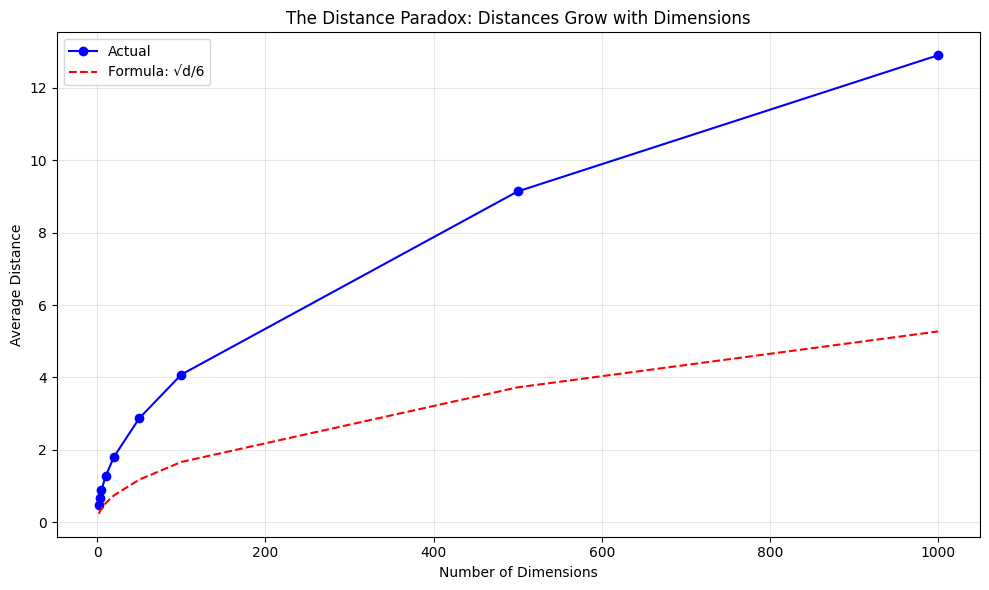


⚠️ In high dimensions, all points are far apart from each other!


In [3]:
def average_distance(n_dimensions, n_points=1000):
    """
    Calculate average Euclidean distance between random points in a unit hypercube.
    """
    points = np.random.rand(n_points, n_dimensions)
    
    # Calculate pairwise distances (sample subset for efficiency)
    sample_size = min(100, n_points)
    sample_points = points[:sample_size]
    
    distances = []
    for i in range(sample_size):
        for j in range(i + 1, sample_size):
            dist = np.linalg.norm(sample_points[i] - sample_points[j])
            distances.append(dist)
    
    return np.mean(distances)

# Test with different dimensions
dimensions = [2, 3, 5, 10, 20, 50, 100, 500, 1000]
avg_distances = []

print("Average distance between random points:")
print("=" * 50)
for d in dimensions:
    avg_dist = average_distance(d)
    avg_distances.append(avg_dist)
    approx_formula = np.sqrt(d) / 6  # Approximate formula
    print(f"{d:4d}D: {avg_dist:7.2f} (formula approx: {approx_formula:7.2f})")

# Visualize the growth
plt.figure(figsize=(10, 6))
plt.plot(dimensions, avg_distances, 'bo-', label='Actual')
plt.plot(dimensions, [np.sqrt(d)/6 for d in dimensions], 'r--', label='Formula: √d/6')
plt.xlabel('Number of Dimensions')
plt.ylabel('Average Distance')
plt.title('The Distance Paradox: Distances Grow with Dimensions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚠️ In high dimensions, all points are far apart from each other!")

### 1.3 Training Data Requirements

**Key Problem**: To reach sufficient density, the number of training instances needed grows **exponentially** with dimensions.

**Example**: With 100 features, you'd need more instances than atoms in the observable universe for instances to be within 0.1 of each other on average!

In [4]:
def required_samples_for_density(n_dimensions, target_density=0.1):
    """
    Estimate required number of samples to achieve target density.
    This is a simplified approximation.
    """
    # To have points within target_density distance, we need roughly:
    # (1/target_density)^n_dimensions samples
    required = (1.0 / target_density) ** n_dimensions
    return required

print("Required samples to maintain density (approx):")
print("=" * 60)
print("Target: Points within 0.1 of each other\n")

for d in [2, 3, 5, 10, 20]:
    required = required_samples_for_density(d, 0.1)
    print(f"{d:2d}D: {required:,.0f} samples")

# Special cases
atoms_in_universe = 1e80
required_100d = required_samples_for_density(100, 0.1)

print(f"\n100D: {required_100d:.2e} samples")
print(f"\nAtoms in observable universe: {atoms_in_universe:.0e}")
print(f"Ratio (100D requirements / atoms): {required_100d / atoms_in_universe:.2e}")
print("\n💡 This is why dimensionality reduction is crucial!")

Required samples to maintain density (approx):
Target: Points within 0.1 of each other

 2D: 100 samples
 3D: 1,000 samples
 5D: 100,000 samples
10D: 10,000,000,000 samples
20D: 100,000,000,000,000,000,000 samples

100D: 1.00e+100 samples

Atoms in observable universe: 1e+80
Ratio (100D requirements / atoms): 1.00e+20

💡 This is why dimensionality reduction is crucial!


---
## 2. Benefits of Dimensionality Reduction

Dimensionality reduction provides three main benefits:

1. **Speed up training** - Smaller datasets train faster
2. **Data visualization** - Reduce to 2D or 3D for plotting and pattern detection
3. **Noise filtering** - May remove unnecessary details

**⚠️ Important**: Always try training with original data first before applying dimensionality reduction, as it adds pipeline complexity and may slightly reduce performance.

---
## 3. Main Approaches to Dimensionality Reduction

There are two main approaches:
1. **Projection**
2. **Manifold Learning**

### 3.1 Projection

**Idea**: Training instances often lie within a much lower-dimensional subspace. Projection maps instances perpendicularly onto this subspace.

**Example**: A 3D dataset lying close to a 2D plane can be projected onto that plane, reducing from 3D to 2D.

Let's create a demonstration:

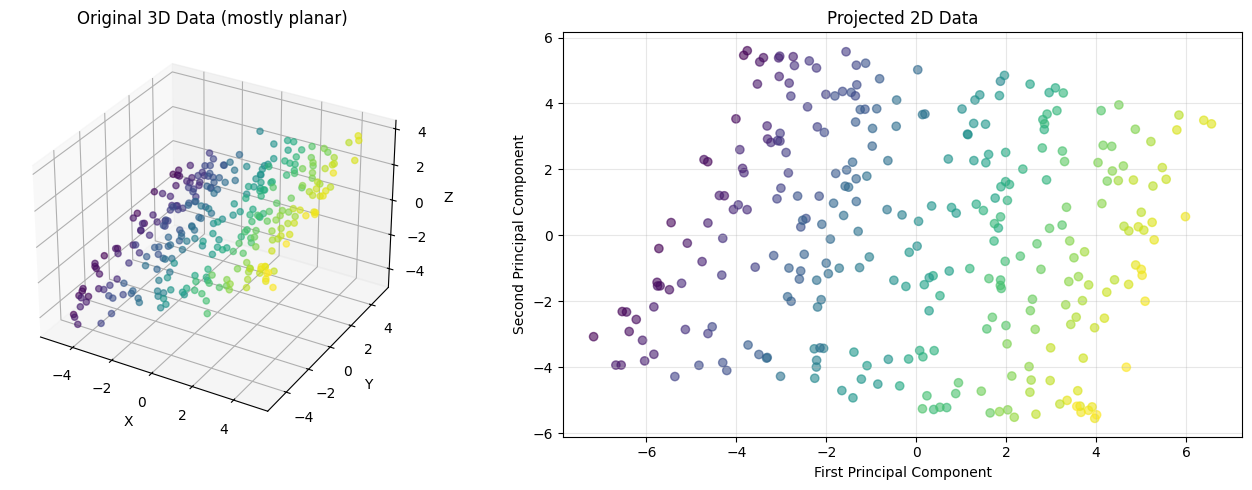

Original shape: (300, 3)
Projected shape: (300, 2)
Variance explained: [0.51904894 0.47184117]
Total variance preserved: 99.09%


In [5]:
# Generate 3D data that lies mostly on a 2D plane
np.random.seed(42)
n_points = 300

# Create points on a 2D plane in 3D space
x = np.random.uniform(-5, 5, n_points)
y = np.random.uniform(-5, 5, n_points)
z = 0.5 * x + 0.3 * y + np.random.normal(0, 0.5, n_points)  # Nearly planar with noise

X_3d = np.c_[x, y, z]

# Visualize the 3D data
fig = plt.figure(figsize=(14, 5))

# Original 3D data
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=X_3d[:, 0], cmap='viridis', alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Original 3D Data (mostly planar)')

# Apply PCA to project to 2D
pca_projection = PCA(n_components=2)
X_2d = pca_projection.fit_transform(X_3d)

# Projected 2D data
ax2 = fig.add_subplot(122)
ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=X_3d[:, 0], cmap='viridis', alpha=0.6)
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_title('Projected 2D Data')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Original shape: {X_3d.shape}")
print(f"Projected shape: {X_2d.shape}")
print(f"Variance explained: {pca_projection.explained_variance_ratio_}")
print(f"Total variance preserved: {pca_projection.explained_variance_ratio_.sum():.2%}")

### 3.2 Limitation of Simple Projection: Swiss Roll

**Problem**: Simple projection doesn't work well for **twisted manifolds** (like the Swiss roll dataset), where projection squashes different layers together.

Let's demonstrate this limitation:

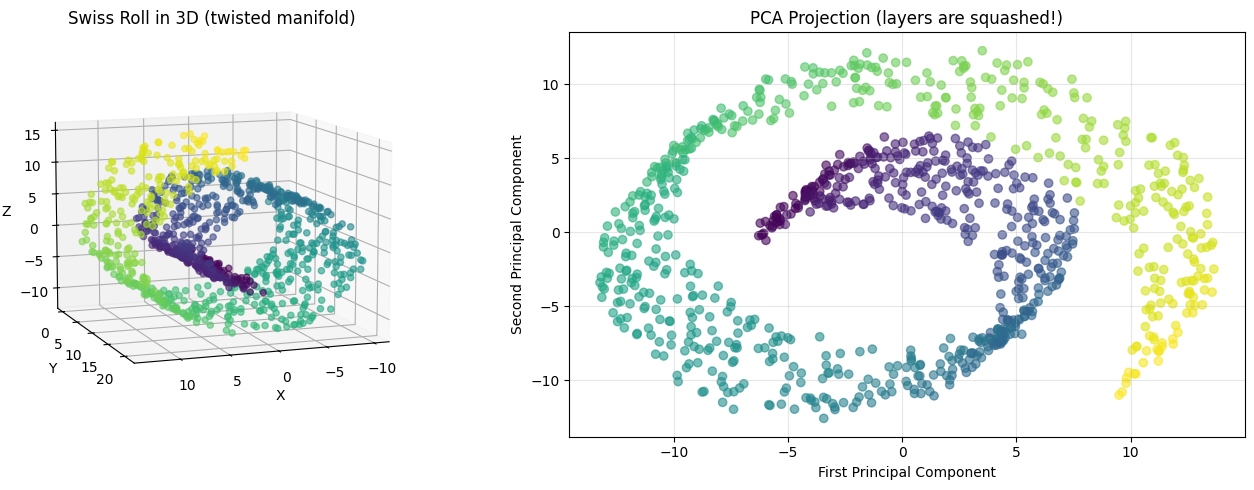

⚠️ Notice how the PCA projection squashes the layers together!
Different layers of the roll overlap in the 2D projection.
This is where Manifold Learning methods (like t-SNE, LLE) work better.


In [6]:
# Generate Swiss Roll dataset
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

# Visualize Swiss Roll
fig = plt.figure(figsize=(14, 5))

# Original 3D Swiss Roll
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap='viridis', alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Swiss Roll in 3D (twisted manifold)')
ax1.view_init(elev=10, azim=70)

# Apply PCA projection
pca_swiss = PCA(n_components=2)
X_swiss_2d = pca_swiss.fit_transform(X_swiss)

# Projected 2D (shows the problem)
ax2 = fig.add_subplot(122)
ax2.scatter(X_swiss_2d[:, 0], X_swiss_2d[:, 1], c=t, cmap='viridis', alpha=0.6)
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_title('PCA Projection (layers are squashed!)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("⚠️ Notice how the PCA projection squashes the layers together!")
print("Different layers of the roll overlap in the 2D projection.")
print("This is where Manifold Learning methods (like t-SNE, LLE) work better.")

### 3.3 Manifold Learning

**Definition**: A **d-dimensional manifold** is a part of an n-dimensional space (where d < n) that locally resembles a d-dimensional hyperplane.

**Manifold Assumption**: Most real-world high-dimensional datasets lie close to a much lower-dimensional manifold.

**Examples**:
- MNIST handwritten digits have constrained features compared to random images
- Images of faces lie on a manifold defined by facial features

**Implicit Assumption**: Tasks become simpler when expressed in the manifold's lower-dimensional space.

**⚠️ Caveat**: This doesn't always hold - sometimes decision boundaries are simpler in the original space!

---
## 4. Principal Component Analysis (PCA) - Basics

**PCA is the most popular dimensionality reduction algorithm.**

It identifies the hyperplane closest to the data and projects onto it.

### 4.1 How PCA Works

PCA works in two main steps:

1. **Identify principal components**: Axes that account for the largest amounts of variance
   - 1st PC: Axis with maximum variance
   - 2nd PC: Orthogonal axis with maximum remaining variance
   - Continue for all dimensions

2. **Project data**: Map to lower dimensions using the first d principal components

### 4.2 Mathematical Foundation: Singular Value Decomposition (SVD)

PCA uses **SVD** to decompose the training set matrix $\mathbf{X}$ into three matrices: $\mathbf{U} \mathbf{\Sigma} \mathbf{V}^\top$

**Principal components matrix** (Equation 8-1):

$$\mathbf{V} = \begin{pmatrix}
| & | & & | \\
\mathbf{c}_1 & \mathbf{c}_2 & \cdots & \mathbf{c}_n \\
| & | & & |
\end{pmatrix}$$

Where $\mathbf{V}$ contains the unit vectors that define all principal components.

### 4.3 Implementation with NumPy

Let's implement PCA from scratch using NumPy's SVD:

In [7]:
# Create a simple dataset for demonstration
np.random.seed(42)
m = 200  # Number of samples
w1, w2 = 0.1, 0.3
noise = 0.1

angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X_demo = np.empty((m, 3))
X_demo[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
X_demo[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
X_demo[:, 2] = X_demo[:, 0] * w1 + X_demo[:, 1] * w2 + noise * np.random.randn(m)

print("Demo dataset shape:", X_demo.shape)
print("\nFirst 5 samples:")
print(X_demo[:5])

Demo dataset shape: (200, 3)

First 5 samples:
[[ 0.74387226  0.71040376  0.40428656]
 [-1.02876931 -0.5285658  -0.23600459]
 [-0.87145573  0.13272972 -0.01356639]
 [-0.35185006  0.46190526  0.06219888]
 [ 1.18228042  0.16221455  0.11813178]]


In [8]:
# Step 1: Center the data (subtract mean)
X_centered = X_demo - X_demo.mean(axis=0)

print("Original data mean:", X_demo.mean(axis=0))
print("Centered data mean:", X_centered.mean(axis=0))  # Should be close to zero
print("\n✓ Data is now centered around the origin")

Original data mean: [0.108222   0.18655844 0.06373489]
Centered data mean: [-1.88737914e-17 -1.12687637e-16 -2.27595720e-17]

✓ Data is now centered around the origin


In [9]:
# Step 2: Perform SVD to get principal components
U, s, Vt = np.linalg.svd(X_centered)

print("SVD decomposition shapes:")
print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

# V contains the principal components (need to transpose Vt)
V = Vt.T

print(f"\nV (principal components) shape: {V.shape}")
print("\nPrincipal components (columns of V):")
print(V)

SVD decomposition shapes:
U shape: (200, 200)
s shape: (3,)
Vt shape: (3, 3)

V (principal components) shape: (3, 3)

Principal components (columns of V):
[[-0.95380288  0.28709268  0.08853165]
 [-0.24882589 -0.92002277  0.30272724]
 [-0.16836191 -0.26671315 -0.94895646]]


In [10]:
# Step 3: Extract first two principal components
c1 = Vt.T[:, 0]  # First principal component
c2 = Vt.T[:, 1]  # Second principal component

print("First Principal Component (c1):", c1)
print("Second Principal Component (c2):", c2)
print("\nVerify orthogonality (dot product should be ~0):", np.dot(c1, c2))

First Principal Component (c1): [-0.95380288 -0.24882589 -0.16836191]
Second Principal Component (c2): [ 0.28709268 -0.92002277 -0.26671315]

Verify orthogonality (dot product should be ~0): -2.945598059419239e-18


### 4.4 Projecting to Lower Dimensions

**Equation 8-2**: Projecting the training set down to d dimensions:

$$\mathbf{X}_{d\text{-proj}} = \mathbf{X} \mathbf{W}_d$$

Where $\mathbf{W}_d$ is the matrix containing the first d columns of $\mathbf{V}$.

Projection matrix W2 shape: (3, 2)
Projected data X2D shape: (200, 2)

First 5 projected samples:
[[-0.79396726 -0.3902887 ]
 [ 1.31287173  0.41145316]
 [ 0.96082801 -0.21111739]
 [ 0.37056325 -0.38499899]
 [-1.02754099  0.31624287]]


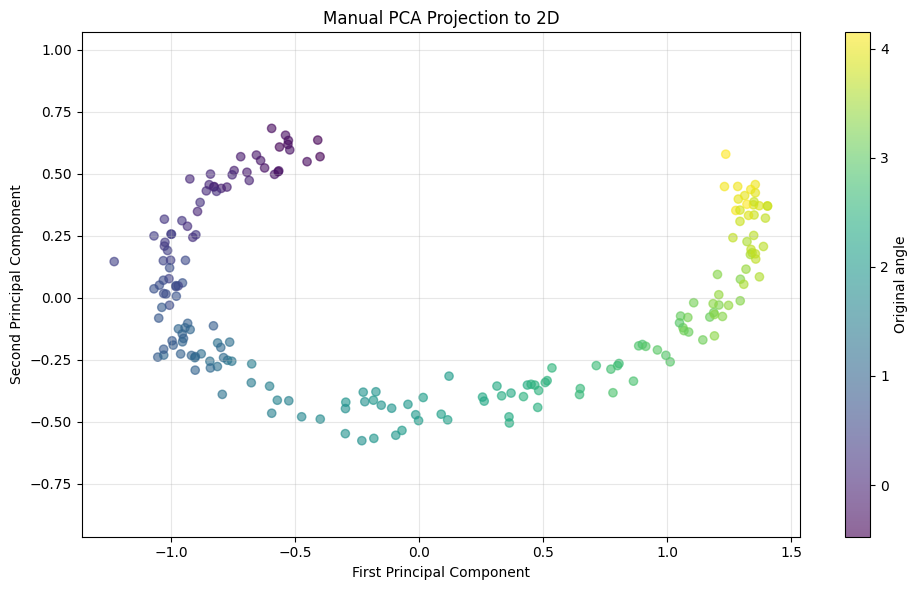

In [11]:
# Project down to 2D using first 2 principal components
W2 = Vt.T[:, :2]  # Matrix with first 2 columns of V
X2D = X_centered.dot(W2)  # Project using matrix multiplication

print("Projection matrix W2 shape:", W2.shape)
print("Projected data X2D shape:", X2D.shape)
print("\nFirst 5 projected samples:")
print(X2D[:5])

# Visualize projection
plt.figure(figsize=(10, 6))
plt.scatter(X2D[:, 0], X2D[:, 1], alpha=0.6, c=angles, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Manual PCA Projection to 2D')
plt.colorbar(label='Original angle')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

### 4.5 Using Scikit-Learn PCA

**Note**: PCA assumes data is centered around the origin. Scikit-Learn handles this automatically.

Let's compare our manual implementation with Scikit-Learn:

In [12]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions using Scikit-Learn
pca = PCA(n_components=2)
X2D_sklearn = pca.fit_transform(X_demo)  # Note: using X_demo, not X_centered

print("Scikit-Learn PCA:")
print(f"Transformed shape: {X2D_sklearn.shape}")
print(f"\nPrincipal components:")
print(pca.components_)
print(f"\nMean (automatically centered):")
print(pca.mean_)

# Compare with our manual implementation
print("\n" + "="*60)
print("Comparison: Manual vs Scikit-Learn")
print("="*60)
print("\nManual implementation (first component):")
print(c1)
print("\nScikit-Learn (first component):")
print(pca.components_[0])
print("\n✓ Results match (possibly with sign flip, which is OK)")

Scikit-Learn PCA:
Transformed shape: (200, 2)

Principal components:
[[ 0.95380288  0.24882589  0.16836191]
 [-0.28709268  0.92002277  0.26671315]]

Mean (automatically centered):
[0.108222   0.18655844 0.06373489]

Comparison: Manual vs Scikit-Learn

Manual implementation (first component):
[-0.95380288 -0.24882589 -0.16836191]

Scikit-Learn (first component):
[0.95380288 0.24882589 0.16836191]

✓ Results match (possibly with sign flip, which is OK)


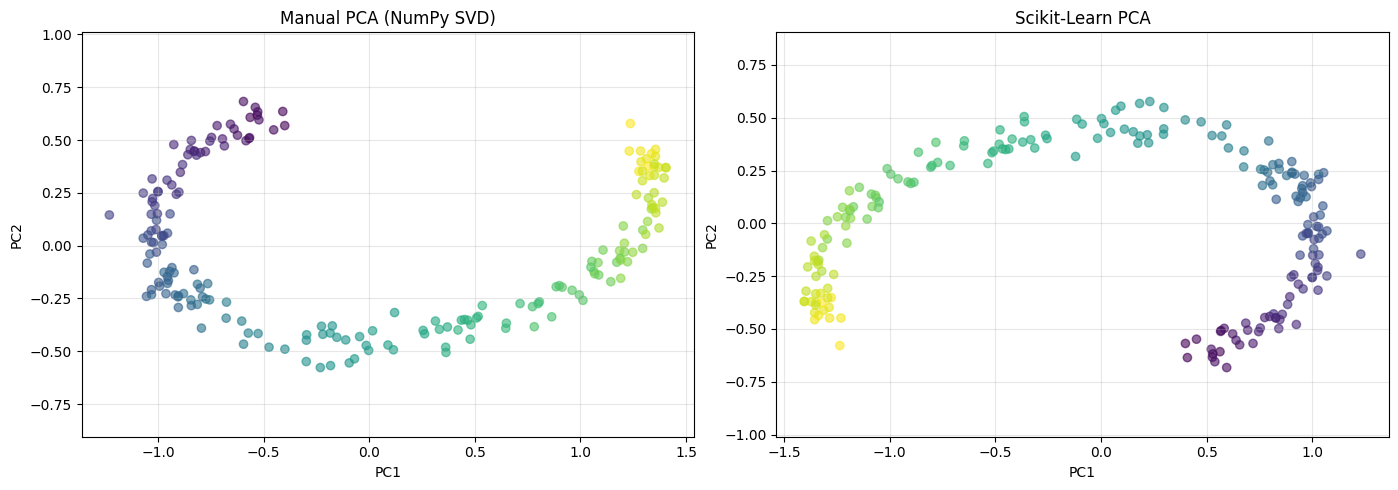

✓ Both methods produce equivalent results!


In [13]:
# Visualize both projections side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Manual PCA
axes[0].scatter(X2D[:, 0], X2D[:, 1], alpha=0.6, c=angles, cmap='viridis')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Manual PCA (NumPy SVD)')
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# Scikit-Learn PCA
axes[1].scatter(X2D_sklearn[:, 0], X2D_sklearn[:, 1], alpha=0.6, c=angles, cmap='viridis')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Scikit-Learn PCA')
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print("✓ Both methods produce equivalent results!")

### 4.6 Explained Variance Ratio

The **explained variance ratio** shows the proportion of variance along each principal component:

Explained Variance Ratio:
[0.8685729  0.12194395 0.00948315]

Interpretation:
PC1: 86.86% of total variance
PC2: 12.19% of total variance
PC3: 0.95% of total variance

Total variance explained by all PCs: 100.00%


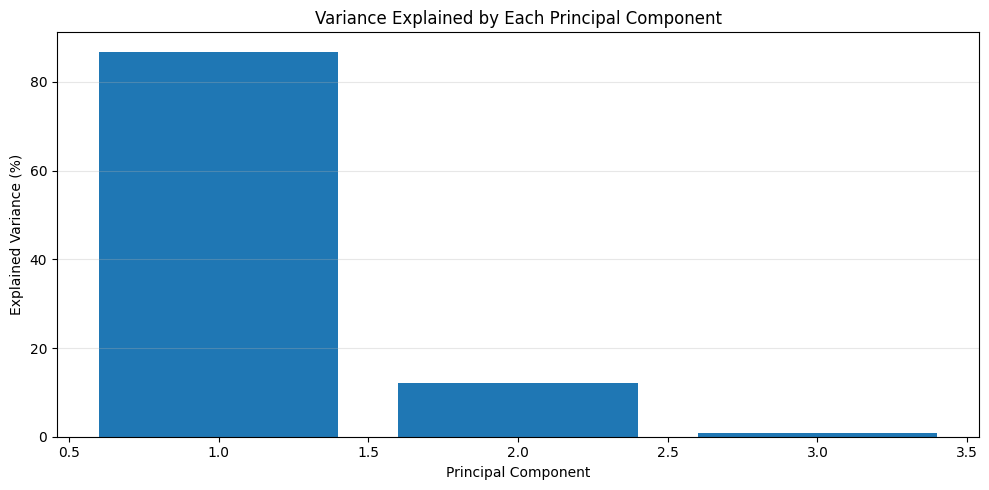

In [14]:
# Fit PCA with all components
pca_full = PCA()
pca_full.fit(X_demo)

print("Explained Variance Ratio:")
print(pca_full.explained_variance_ratio_)
print(f"\nInterpretation:")
for i, var_ratio in enumerate(pca_full.explained_variance_ratio_):
    print(f"PC{i+1}: {var_ratio*100:.2f}% of total variance")

print(f"\nTotal variance explained by all PCs: {pca_full.explained_variance_ratio_.sum()*100:.2f}%")

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_ * 100)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Variance Explained by Each Principal Component')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
---
# PART 2: ADVANCED PCA TECHNIQUES
---
---

## 5. Choosing the Number of Dimensions

One of the key decisions when using PCA is: **How many dimensions should we keep?**

We'll explore three methods to make this decision.

### 5.1 Generate Sample Dataset

Let's create a high-dimensional dataset for demonstration:

In [15]:
# Create a synthetic dataset with 20 features
np.random.seed(42)
n_samples = 500
n_features = 20

# Create data with varying amounts of variance in each dimension
X = np.random.randn(n_samples, n_features)

# Make some dimensions more important by scaling
for i in range(n_features):
    X[:, i] *= (n_features - i) / n_features

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")

Dataset shape: (500, 20)
Number of samples: 500
Number of features: 20


### Method 1: Compute Cumulative Variance

Find the number of dimensions needed to preserve a target amount of variance (e.g., 95%):

Explained variance ratio per component:
[0.14492887 0.12978316 0.11177319 0.09911337 0.09203776 0.0833186
 0.06651178 0.06092441 0.04510313 0.03660279 0.03248919 0.0293518
 0.01980739 0.01608141 0.01218496 0.00914247 0.00585366 0.00331596
 0.00137447 0.00030161]

Cumulative variance:
[0.14492887 0.27471203 0.38648522 0.4855986  0.57763636 0.66095496
 0.72746674 0.78839115 0.83349428 0.87009708 0.90258626 0.93193807
 0.95174545 0.96782686 0.98001182 0.98915429 0.99500795 0.99832392
 0.99969839 1.        ]

✓ Number of components for 95% variance: 13


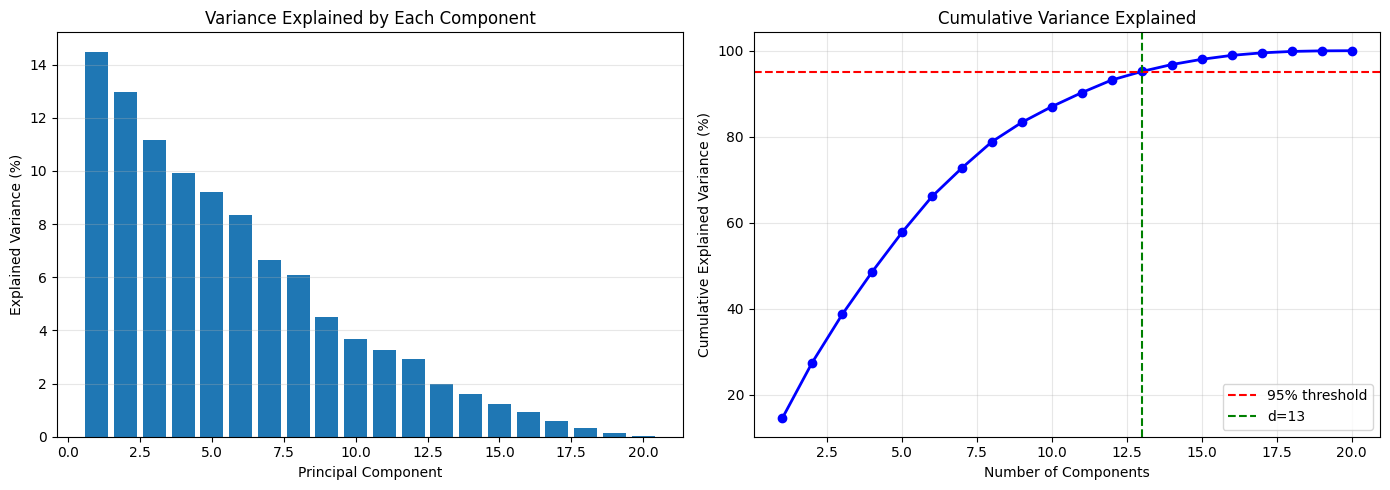

In [16]:
# Fit PCA with all components
pca = PCA()
pca.fit(X)

# Compute cumulative sum of explained variance
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
d = np.argmax(cumsum >= 0.95) + 1

print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_)
print(f"\nCumulative variance:")
print(cumsum)
print(f"\n✓ Number of components for 95% variance: {d}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_ * 100)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Variance Explained by Each Component')
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative explained variance
axes[1].plot(range(1, len(cumsum) + 1), cumsum * 100, 'bo-', linewidth=2)
axes[1].axhline(y=95, color='r', linestyle='--', label='95% threshold')
axes[1].axvline(x=d, color='g', linestyle='--', label=f'd={d}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Method 2: Set Target Variance Directly

**Simpler approach**: Let Scikit-Learn automatically choose the number of dimensions:

In [17]:
# Set n_components to a float between 0 and 1 to specify target variance
pca_95 = PCA(n_components=0.95)  # Preserve 95% variance
X_reduced = pca_95.fit_transform(X)

print(f"Original dimensions: {X.shape[1]}")
print(f"Reduced dimensions: {X_reduced.shape[1]}")
print(f"\nActual variance preserved: {pca_95.explained_variance_ratio_.sum():.4f}")
print(f"Variance ratio per component:")
for i, var in enumerate(pca_95.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\n✓ Automatically selected {X_reduced.shape[1]} components")

Original dimensions: 20
Reduced dimensions: 13

Actual variance preserved: 0.9517
Variance ratio per component:
  PC1: 0.1449 (14.49%)
  PC2: 0.1298 (12.98%)
  PC3: 0.1118 (11.18%)
  PC4: 0.0991 (9.91%)
  PC5: 0.0920 (9.20%)
  PC6: 0.0833 (8.33%)
  PC7: 0.0665 (6.65%)
  PC8: 0.0609 (6.09%)
  PC9: 0.0451 (4.51%)
  PC10: 0.0366 (3.66%)
  PC11: 0.0325 (3.25%)
  PC12: 0.0294 (2.94%)
  PC13: 0.0198 (1.98%)

✓ Automatically selected 13 components


### Method 3: Plot Explained Variance (Elbow Method)

Look for an **"elbow"** in the plot where variance stops growing fast:

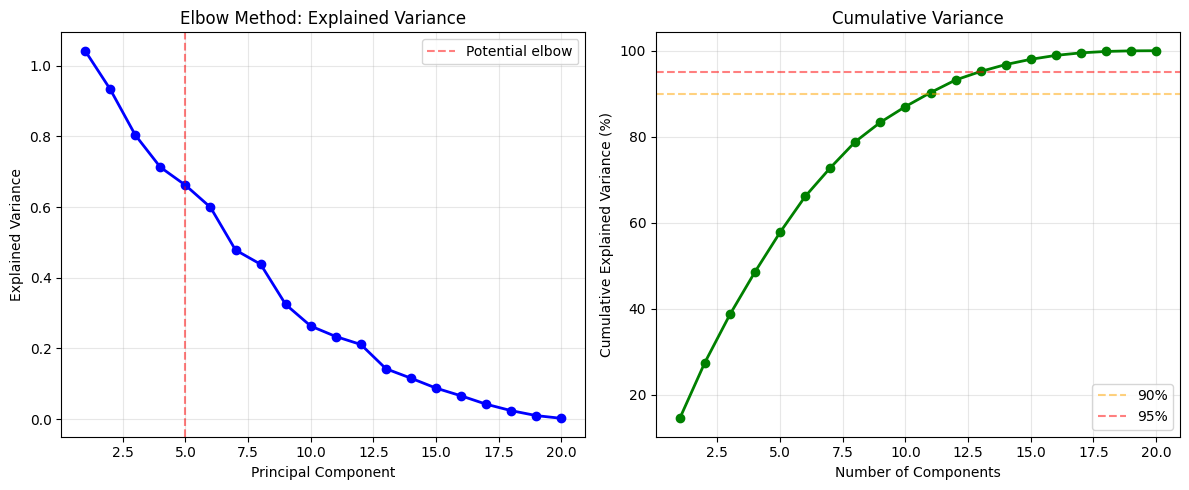

📊 Look for the 'elbow' where adding more components doesn't add much variance.


In [18]:
# Fit PCA with all components
pca_full = PCA()
pca_full.fit(X)

# Plot to find the elbow
plt.figure(figsize=(12, 5))

# Left plot: Explained variance
plt.subplot(121)
plt.plot(range(1, len(pca_full.explained_variance_) + 1), 
         pca_full.explained_variance_, 'bo-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.title('Elbow Method: Explained Variance')
plt.grid(True, alpha=0.3)

# Annotate potential elbow
elbow_point = 5  # Visual inspection suggests around PC5
plt.axvline(x=elbow_point, color='r', linestyle='--', alpha=0.5, label='Potential elbow')
plt.legend()

# Right plot: Cumulative variance
plt.subplot(122)
cumsum_full = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum_full) + 1), cumsum_full * 100, 'go-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Variance')
plt.grid(True, alpha=0.3)
plt.axhline(y=90, color='orange', linestyle='--', alpha=0.5, label='90%')
plt.axhline(y=95, color='r', linestyle='--', alpha=0.5, label='95%')
plt.legend()

plt.tight_layout()
plt.show()

print("📊 Look for the 'elbow' where adding more components doesn't add much variance.")

---
## 6. PCA for Compression

PCA can be used to **compress data** by reducing dimensions, then **reconstruct** it later.

### Example: MNIST Dataset

Let's apply PCA to the MNIST dataset:
- **Original**: 784 features (28×28 pixels)
- **Reduced**: ~154 features (with 95% variance)
- **Compression**: ~20% of original size
- **Benefit**: Significantly speeds up classification algorithms

In [44]:
# Load MNIST dataset (this may take a moment)
print("Loading MNIST dataset...")
try:
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X_mnist, y_mnist = mnist["data"], mnist["target"]
    
    # Use a subset for faster computation
    X_train = X_mnist[:10000]
    y_train = y_mnist[:10000].astype(int)  # Convert strings to integers
    
    print(f"✓ Dataset loaded successfully!")
    print(f"Shape: {X_train.shape}")
    print(f"Original features: {X_train.shape[1]}")
except Exception as e:
    print(f"Could not load MNIST: {e}")
    print("Creating synthetic data instead...")
    X_train = np.random.rand(1000, 784)
    y_train = np.random.randint(0, 10, 1000)

Loading MNIST dataset...
✓ Dataset loaded successfully!
Shape: (10000, 784)
Original features: 784
✓ Dataset loaded successfully!
Shape: (10000, 784)
Original features: 784


In [20]:
# Apply PCA with 95% variance preservation
print("Applying PCA for compression...")
pca_mnist = PCA(n_components=0.95)
X_train_reduced = pca_mnist.fit_transform(X_train)

print(f"\nCompression Results:")
print(f"="*50)
print(f"Original dimensions: {X_train.shape[1]}")
print(f"Reduced dimensions: {X_train_reduced.shape[1]}")
print(f"Compression ratio: {X_train_reduced.shape[1] / X_train.shape[1] * 100:.1f}%")
print(f"Variance preserved: {pca_mnist.explained_variance_ratio_.sum():.4f}")

# Calculate size reduction
original_size = X_train.nbytes / 1024  # KB
reduced_size = X_train_reduced.nbytes / 1024  # KB
print(f"\nMemory Usage:")
print(f"Original: {original_size:.2f} KB")
print(f"Reduced: {reduced_size:.2f} KB")
print(f"Savings: {(1 - reduced_size/original_size)*100:.1f}%")

Applying PCA for compression...

Compression Results:
Original dimensions: 784
Reduced dimensions: 150
Compression ratio: 19.1%
Variance preserved: 0.9500

Memory Usage:
Original: 61250.00 KB
Reduced: 11718.75 KB
Savings: 80.9%

Compression Results:
Original dimensions: 784
Reduced dimensions: 150
Compression ratio: 19.1%
Variance preserved: 0.9500

Memory Usage:
Original: 61250.00 KB
Reduced: 11718.75 KB
Savings: 80.9%


### Reconstruction from Compressed Data

We can reconstruct the original data using the inverse transform.

**Equation 8-3**: PCA inverse transformation, back to the original number of dimensions:

$$\mathbf{X}_{\text{recovered}} = \mathbf{X}_{d\text{-proj}}\mathbf{W}_d^{\top}$$

**Note**: There will be some **reconstruction error** (information loss).

Recovered shape: (10000, 784)
Original shape: (10000, 784)

Reconstruction error (MSE): 218.610425

Reconstruction error (MSE): 218.610425


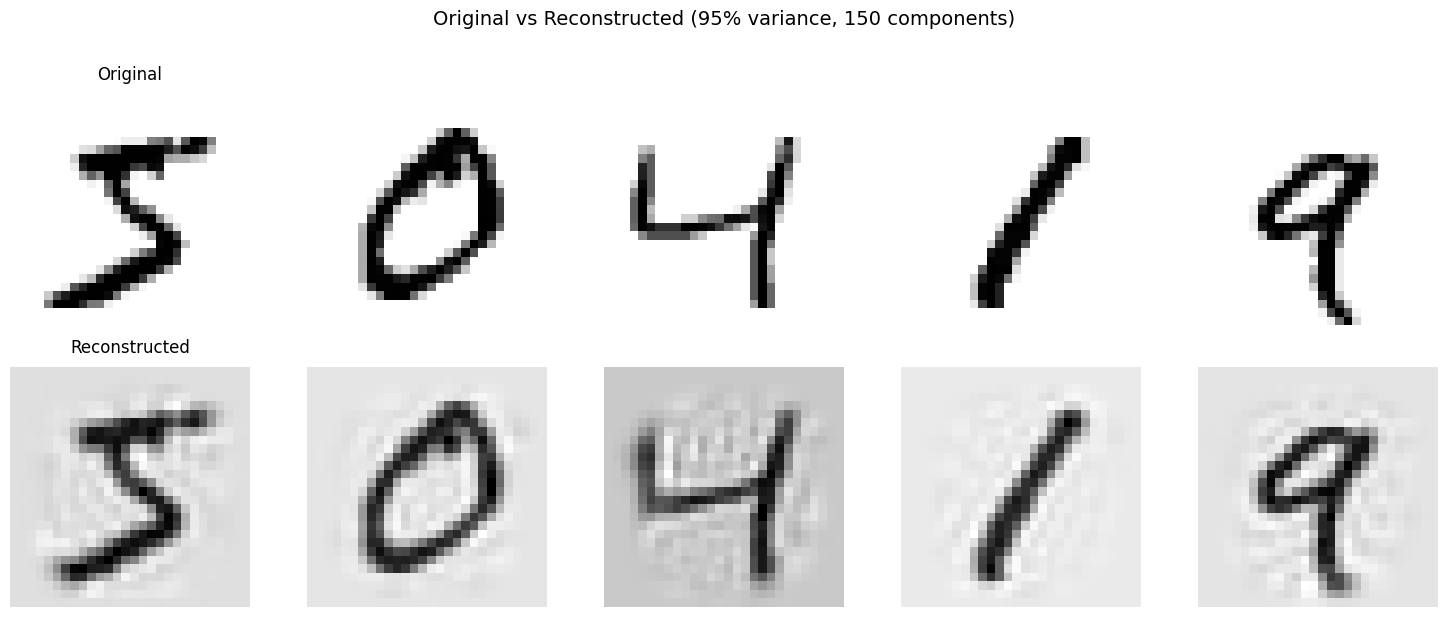


✓ Despite compression, images are still recognizable!


In [21]:
# Reconstruct the data
X_train_recovered = pca_mnist.inverse_transform(X_train_reduced)

print(f"Recovered shape: {X_train_recovered.shape}")
print(f"Original shape: {X_train.shape}")

# Calculate reconstruction error
reconstruction_error = mean_squared_error(X_train, X_train_recovered)
print(f"\nReconstruction error (MSE): {reconstruction_error:.6f}")

# Visualize original vs reconstructed images
n_images = 5
fig, axes = plt.subplots(2, n_images, figsize=(15, 6))

for i in range(n_images):
    # Original
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap='binary')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=12, pad=10)
    
    # Reconstructed
    axes[1, i].imshow(X_train_recovered[i].reshape(28, 28), cmap='binary')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=12, pad=10)

plt.suptitle(f'Original vs Reconstructed (95% variance, {X_train_reduced.shape[1]} components)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Despite compression, images are still recognizable!")

---
## 7. Randomized PCA

**Randomized PCA** uses a stochastic algorithm for faster approximation.

**Complexity**: 
- Standard PCA: O(m × n²) + O(n³)
- Randomized PCA: O(m × d²) + O(d³)

**When it's used automatically**:
- m or n > 500
- d < 80% of m or n

In [22]:
# Create a larger dataset to see the speed difference
np.random.seed(42)
X_large = np.random.randn(5000, 1000)
n_components = 100

print(f"Dataset shape: {X_large.shape}")
print(f"Target components: {n_components}\n")

# Standard PCA
print("Running Standard PCA...")
start_time = time.time()
pca_standard = PCA(n_components=n_components, svd_solver='full')
X_reduced_standard = pca_standard.fit_transform(X_large)
time_standard = time.time() - start_time
print(f"✓ Standard PCA time: {time_standard:.3f} seconds")

# Randomized PCA
print("\nRunning Randomized PCA...")
start_time = time.time()
pca_randomized = PCA(n_components=n_components, svd_solver='randomized')
X_reduced_randomized = pca_randomized.fit_transform(X_large)
time_randomized = time.time() - start_time
print(f"✓ Randomized PCA time: {time_randomized:.3f} seconds")

# Compare
print(f"\n" + "="*60)
speedup = time_standard / time_randomized
print(f"Speedup: {speedup:.2f}x faster")
print(f"Time saved: {time_standard - time_randomized:.3f} seconds")

# Compare quality
variance_diff = abs(pca_standard.explained_variance_ratio_.sum() - 
                    pca_randomized.explained_variance_ratio_.sum())
print(f"\nVariance difference: {variance_diff:.6f}")
print("✓ Randomized PCA is much faster with minimal quality loss!")

Dataset shape: (5000, 1000)
Target components: 100

Running Standard PCA...
✓ Standard PCA time: 1.878 seconds

Running Randomized PCA...
✓ Standard PCA time: 1.878 seconds

Running Randomized PCA...
✓ Randomized PCA time: 0.600 seconds

Speedup: 3.13x faster
Time saved: 1.278 seconds

Variance difference: 0.011213
✓ Randomized PCA is much faster with minimal quality loss!
✓ Randomized PCA time: 0.600 seconds

Speedup: 3.13x faster
Time saved: 1.278 seconds

Variance difference: 0.011213
✓ Randomized PCA is much faster with minimal quality loss!


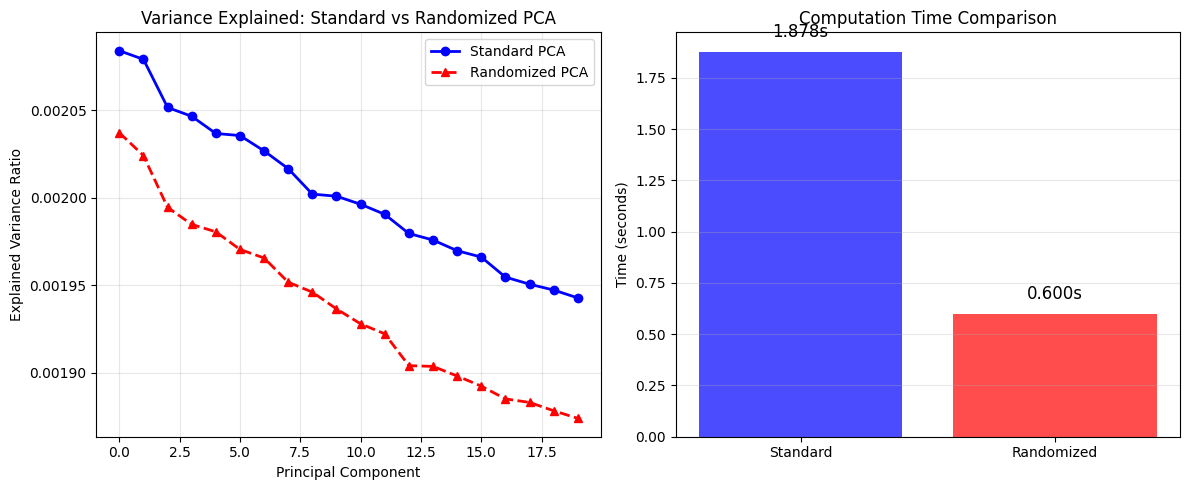

In [23]:
# Compare explained variance ratios
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.plot(pca_standard.explained_variance_ratio_[:20], 'bo-', 
         label='Standard PCA', linewidth=2, markersize=6)
plt.plot(pca_randomized.explained_variance_ratio_[:20], 'r^--', 
         label='Randomized PCA', linewidth=2, markersize=6)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained: Standard vs Randomized PCA')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(122)
methods = ['Standard', 'Randomized']
times = [time_standard, time_randomized]
colors = ['blue', 'red']
plt.bar(methods, times, color=colors, alpha=0.7)
plt.ylabel('Time (seconds)')
plt.title('Computation Time Comparison')
plt.grid(True, alpha=0.3, axis='y')

for i, (method, t) in enumerate(zip(methods, times)):
    plt.text(i, t + 0.05, f'{t:.3f}s', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

---
## 8. Incremental PCA

**Incremental PCA (IPCA)** processes data in **mini-batches**, making it suitable for:
- Datasets too large to fit in memory
- Online learning scenarios

**Key advantage**: Can be used with datasets stored on disk using `np.memmap`

In [24]:
# Create a dataset
np.random.seed(42)
X_large = np.random.randn(3000, 100)

print(f"Dataset shape: {X_large.shape}")

# Process in mini-batches
n_batches = 10
n_components = 20

inc_pca = IncrementalPCA(n_components=n_components)

print(f"\nProcessing in {n_batches} batches...")
batch_num = 1
for X_batch in np.array_split(X_large, n_batches):
    print(f"  Batch {batch_num}/{n_batches} - shape: {X_batch.shape}")
    inc_pca.partial_fit(X_batch)
    batch_num += 1

# Transform the data
X_reduced_inc = inc_pca.transform(X_large)

print(f"\n✓ Incremental PCA complete!")
print(f"Original shape: {X_large.shape}")
print(f"Reduced shape: {X_reduced_inc.shape}")
print(f"Variance explained: {inc_pca.explained_variance_ratio_.sum():.4f}")

Dataset shape: (3000, 100)

Processing in 10 batches...
  Batch 1/10 - shape: (300, 100)
  Batch 2/10 - shape: (300, 100)
  Batch 3/10 - shape: (300, 100)
  Batch 4/10 - shape: (300, 100)
  Batch 5/10 - shape: (300, 100)
  Batch 6/10 - shape: (300, 100)
  Batch 7/10 - shape: (300, 100)
  Batch 8/10 - shape: (300, 100)
  Batch 9/10 - shape: (300, 100)
  Batch 10/10 - shape: (300, 100)

✓ Incremental PCA complete!
Original shape: (3000, 100)
Reduced shape: (3000, 20)
Variance explained: 0.2287


Variance Explained Comparison:
Standard PCA: 0.253899
Incremental PCA: 0.228724
Difference: 0.025175


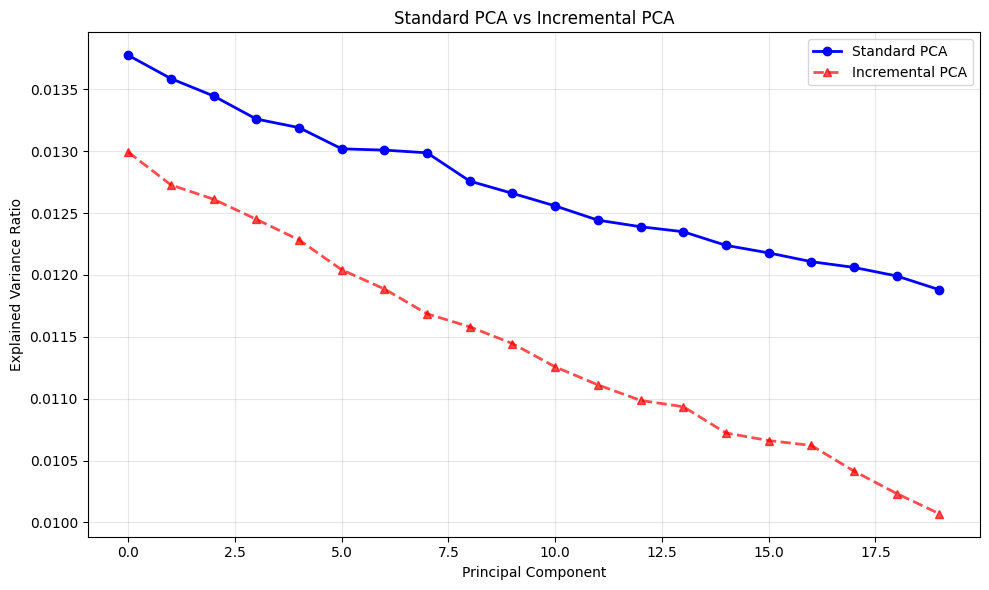


✓ Results are very similar! IPCA is great for large datasets.


In [25]:
# Standard PCA for comparison
pca_standard = PCA(n_components=n_components)
X_reduced_standard = pca_standard.fit_transform(X_large)

# Compare explained variance
print("Variance Explained Comparison:")
print("="*60)
print(f"Standard PCA: {pca_standard.explained_variance_ratio_.sum():.6f}")
print(f"Incremental PCA: {inc_pca.explained_variance_ratio_.sum():.6f}")
print(f"Difference: {abs(pca_standard.explained_variance_ratio_.sum() - inc_pca.explained_variance_ratio_.sum()):.6f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.plot(pca_standard.explained_variance_ratio_, 'bo-', 
         label='Standard PCA', linewidth=2, markersize=6)
plt.plot(inc_pca.explained_variance_ratio_, 'r^--', 
         label='Incremental PCA', linewidth=2, markersize=6, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Standard PCA vs Incremental PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Results are very similar! IPCA is great for large datasets.")

#### 8.3. Memory-Mapped Files for Truly Large Datasets

For datasets too large to fit in memory, use `numpy.memmap` with Incremental PCA:

In [33]:
# Example: Create and use a memory-mapped array
import os
import gc

filename = 'lar_dataset.dat'
n_samples = 10000
n_features = 100

# Remove old file if exists (before creating new memmap)
if os.path.exists(filename):
    try:
        os.remove(filename)
    except PermissionError:
        print(f"Note: Could not delete old {filename}, will overwrite.")

# Create a memory-mapped array on disk
X_memmap = np.memmap(filename, dtype='float32', mode='w+', shape=(n_samples, n_features))

# Fill it with data (in chunks to save memory)
print("Creating memory-mapped dataset...")
for i in range(0, n_samples, 1000):
    end_idx = min(i + 1000, n_samples)
    X_memmap[i:end_idx] = np.random.randn(end_idx - i, n_features)

# Flush to ensure data is written
X_memmap.flush()

# Use Incremental PCA with memory-mapped data
print("\nProcessing with Incremental PCA...")
inc_pca_memmap = IncrementalPCA(n_components=20, batch_size=500)

# Process in batches
for i in range(0, n_samples, 500):
    end_idx = min(i + 500, n_samples)
    X_batch = X_memmap[i:end_idx].copy()  # Copy to regular array
    inc_pca_memmap.partial_fit(X_batch)
    if (i // 500 + 1) % 5 == 0:
        print(f"  Processed {end_idx}/{n_samples} samples")

print(f"\n✓ Successfully processed {n_samples} samples from disk!")
print(f"  Explained variance: {inc_pca_memmap.explained_variance_ratio_.sum():.4f}")

# Clean up - Proper cleanup for Windows
del X_memmap  # Delete the memmap object
gc.collect()  # Force garbage collection
print(f"\n  Memory-mapped file created: {filename}")
print(f"  Note: On Windows, you may need to restart the kernel to delete the file.")
print(f"  Or manually delete it after closing this notebook.")

Creating memory-mapped dataset...

Processing with Incremental PCA...
  Processed 2500/10000 samples
  Processed 5000/10000 samples
  Processed 7500/10000 samples
  Processed 10000/10000 samples

✓ Successfully processed 10000 samples from disk!
  Explained variance: 0.2115

  Memory-mapped file created: lar_dataset.dat
  Note: On Windows, you may need to restart the kernel to delete the file.
  Or manually delete it after closing this notebook.
  Processed 5000/10000 samples
  Processed 7500/10000 samples
  Processed 10000/10000 samples

✓ Successfully processed 10000 samples from disk!
  Explained variance: 0.2115

  Memory-mapped file created: lar_dataset.dat
  Note: On Windows, you may need to restart the kernel to delete the file.
  Or manually delete it after closing this notebook.


---

### 9. Kernel PCA

**Kernel PCA** applies the **kernel trick** to perform complex nonlinear projections for dimensionality reduction. It's useful when data has complex nonlinear structures.

**Mathematical Formula:**

For a kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$, Kernel PCA computes eigenvectors of the centered kernel matrix:

$$\tilde{K} = K - \mathbf{1}_n K - K \mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n$$

where $\mathbf{1}_n = \frac{1}{n}\mathbf{1}\mathbf{1}^T$ and $\mathbf{1}$ is a column vector of ones.

**Common Kernels:**
- **Linear**: $K(\mathbf{a}, \mathbf{b}) = \mathbf{a}^T \mathbf{b}$
- **Polynomial**: $K(\mathbf{a}, \mathbf{b}) = (\gamma \mathbf{a}^T \mathbf{b} + r)^d$
- **RBF (Gaussian)**: $K(\mathbf{a}, \mathbf{b}) = \exp(-\gamma \|\mathbf{a} - \mathbf{b}\|^2)$
- **Sigmoid**: $K(\mathbf{a}, \mathbf{b}) = \tanh(\gamma \mathbf{a}^T \mathbf{b} + r)$

#### 9.1. Kernel PCA on Swiss Roll Dataset

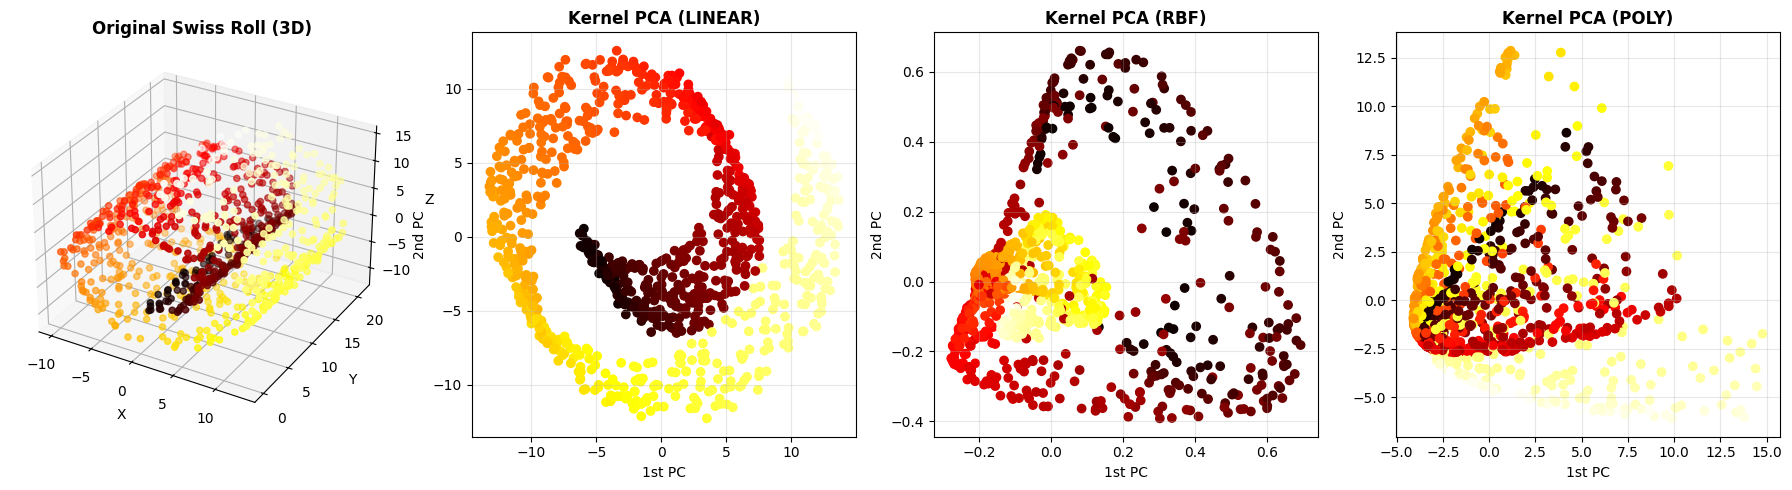

✓ RBF kernel works best for unrolling the Swiss Roll!
  Linear kernel fails to capture nonlinear structure.
  Polynomial kernel provides intermediate results.


In [35]:
# Generate Swiss Roll dataset
from sklearn.datasets import make_swiss_roll
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

# Apply different kernel PCAs
from sklearn.decomposition import KernelPCA

# Note: Using fit_inverse_transform=False to avoid singular matrix issues
kernels = ['linear', 'rbf', 'poly']
gammas = [None, 0.04, None]  # gamma for RBF kernel
kernel_params = [
    {'kernel': 'linear'},
    {'kernel': 'rbf', 'gamma': 0.04},
    {'kernel': 'poly', 'degree': 3, 'gamma': 0.01}
]

fig = plt.figure(figsize=(18, 5))

# Original 3D data
ax = fig.add_subplot(141, projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap=plt.cm.hot)
ax.set_title("Original Swiss Roll (3D)", fontsize=12, fontweight='bold')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Apply different kernels
for idx, params in enumerate(kernel_params):
    kpca = KernelPCA(n_components=2, random_state=42, **params)
    X_reduced = kpca.fit_transform(X_swiss)
    
    ax = fig.add_subplot(1, 4, idx + 2)
    ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot)
    kernel_name = params['kernel'].upper()
    ax.set_title(f"Kernel PCA ({kernel_name})", fontsize=12, fontweight='bold')
    ax.set_xlabel("1st PC")
    ax.set_ylabel("2nd PC")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ RBF kernel works best for unrolling the Swiss Roll!")
print("  Linear kernel fails to capture nonlinear structure.")
print("  Polynomial kernel provides intermediate results.")

#### 9.2. Selecting Kernel and Hyperparameters

**Method 1: Use Pipeline with Grid Search (for supervised learning)**

Best Parameters Found:
Kernel: rbf
Gamma: 0.0478
Best CV Score: 0.8420


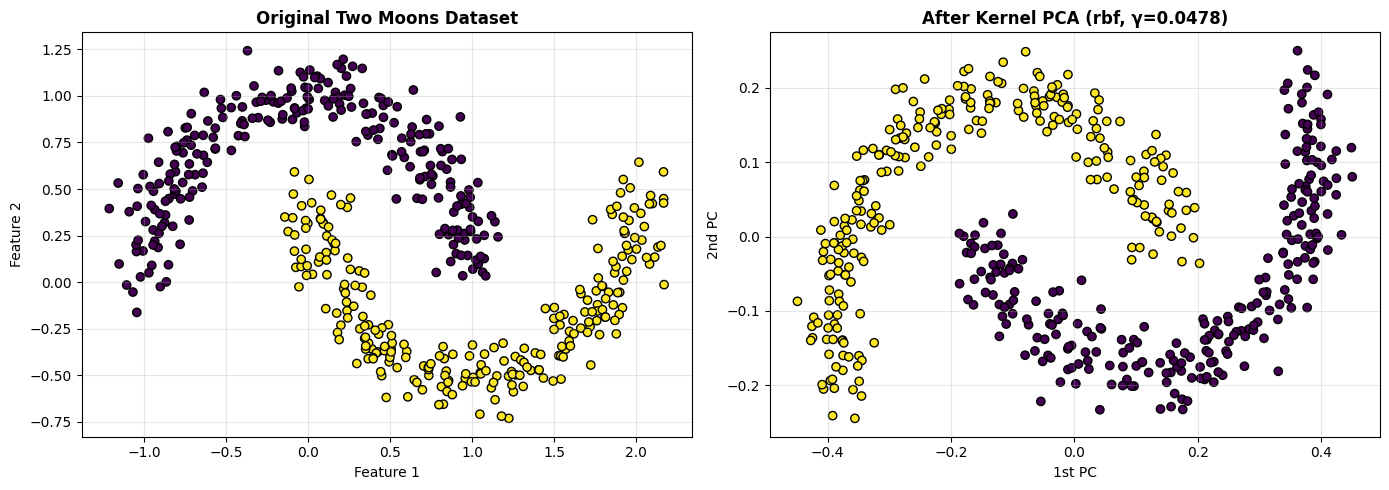


✓ Grid Search helps find optimal kernel and hyperparameters!


In [36]:
# Generate a dataset with clear classes
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.1, random_state=42)

# Create pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

clf = Pipeline([
    ("kpca", KernelPCA(n_components=2)),
    ("log_reg", LogisticRegression(max_iter=1000, random_state=42))
])

# Grid search
param_grid = [{
    "kpca__gamma": np.linspace(0.03, 0.05, 10),
    "kpca__kernel": ["rbf", "sigmoid"]
}]

grid_search = GridSearchCV(clf, param_grid, cv=3, scoring='accuracy', verbose=0)
grid_search.fit(X_moons, y_moons)

print("Best Parameters Found:")
print("="*60)
print(f"Kernel: {grid_search.best_params_['kpca__kernel']}")
print(f"Gamma: {grid_search.best_params_['kpca__gamma']:.4f}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Visualize results
kpca_best = KernelPCA(n_components=2, 
                      kernel=grid_search.best_params_['kpca__kernel'],
                      gamma=grid_search.best_params_['kpca__gamma'])
X_moons_reduced = kpca_best.fit_transform(X_moons)

plt.figure(figsize=(14, 5))

plt.subplot(121)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', edgecolors='k')
plt.title("Original Two Moons Dataset", fontsize=12, fontweight='bold')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)

plt.subplot(122)
plt.scatter(X_moons_reduced[:, 0], X_moons_reduced[:, 1], c=y_moons, 
            cmap='viridis', edgecolors='k')
plt.title(f"After Kernel PCA ({grid_search.best_params_['kpca__kernel']}, γ={grid_search.best_params_['kpca__gamma']:.4f})", 
          fontsize=12, fontweight='bold')
plt.xlabel("1st PC")
plt.ylabel("2nd PC")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Grid Search helps find optimal kernel and hyperparameters!")

**Method 2: Minimize Reconstruction Error (for unsupervised learning)**

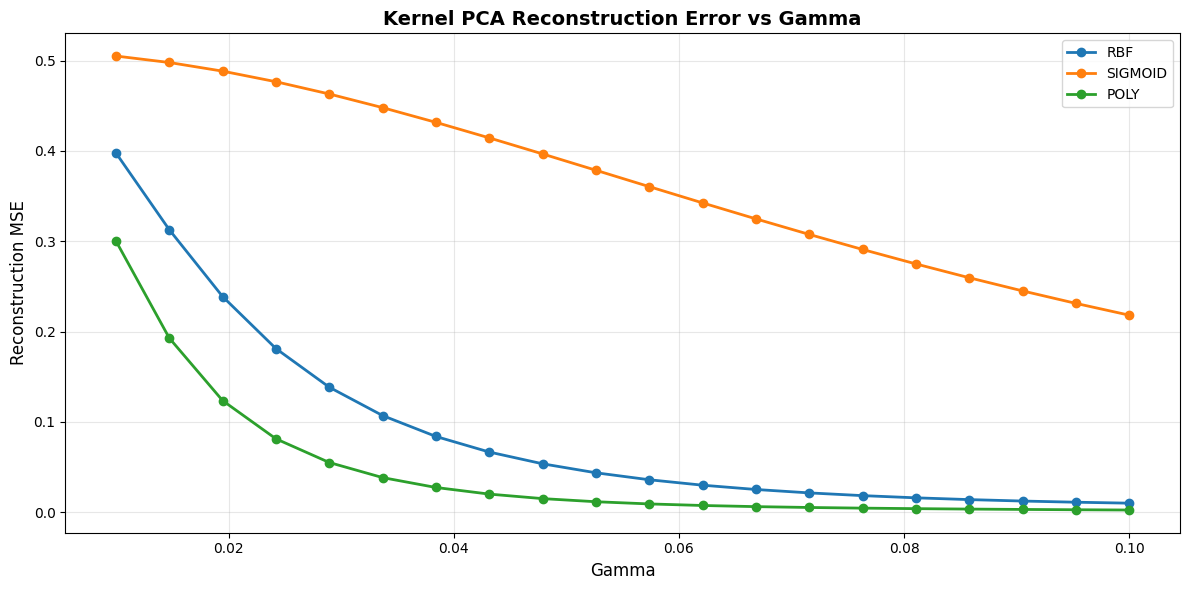

Best Configuration (Minimum Reconstruction Error):
Kernel: poly
Gamma: 0.1000
Reconstruction MSE: 0.002469

✓ Lower reconstruction error means better preservation of data structure!


In [37]:
# Test different kernels and gammas
from sklearn.metrics import mean_squared_error

gammas_to_test = np.linspace(0.01, 0.1, 20)
kernels_to_test = ['rbf', 'sigmoid', 'poly']

results = []

for kernel in kernels_to_test:
    kernel_errors = []
    for gamma in gammas_to_test:
        # Fit Kernel PCA with inverse transform
        kpca = KernelPCA(n_components=2, kernel=kernel, gamma=gamma,
                         fit_inverse_transform=True, random_state=42)
        X_reduced = kpca.fit_transform(X_moons)
        X_reconstructed = kpca.inverse_transform(X_reduced)
        
        # Calculate reconstruction error
        mse = mean_squared_error(X_moons, X_reconstructed)
        kernel_errors.append(mse)
    
    results.append((kernel, kernel_errors))

# Plot results
plt.figure(figsize=(12, 6))
for kernel, errors in results:
    plt.plot(gammas_to_test, errors, marker='o', label=f'{kernel.upper()}', linewidth=2)

plt.xlabel('Gamma', fontsize=12)
plt.ylabel('Reconstruction MSE', fontsize=12)
plt.title('Kernel PCA Reconstruction Error vs Gamma', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find best kernel and gamma
best_kernel = None
best_gamma = None
best_error = float('inf')

for kernel, errors in results:
    min_error_idx = np.argmin(errors)
    if errors[min_error_idx] < best_error:
        best_error = errors[min_error_idx]
        best_kernel = kernel
        best_gamma = gammas_to_test[min_error_idx]

print("Best Configuration (Minimum Reconstruction Error):")
print("="*60)
print(f"Kernel: {best_kernel}")
print(f"Gamma: {best_gamma:.4f}")
print(f"Reconstruction MSE: {best_error:.6f}")
print("\n✓ Lower reconstruction error means better preservation of data structure!")

---

## Part 3: LLE and Other Techniques

### 10. Locally Linear Embedding (LLE)

**Locally Linear Embedding (LLE)** is a **Manifold Learning** technique that works by:
1. Measuring how each training instance linearly relates to its closest neighbors
2. Finding a low-dimensional representation where these relationships are best preserved

**Key Characteristics:**
- **Nonlinear** dimensionality reduction
- Good at **unrolling** twisted manifolds
- **No projection** - cannot be applied to new instances directly
- Scales poorly to very large datasets

**Mathematical Intuition:**

For each instance $\mathbf{x}_i$:
1. Find its $k$ nearest neighbors
2. Find weights $w_{i,j}$ that best reconstruct $\mathbf{x}_i$ from its neighbors:
   $$\mathbf{x}_i \approx \sum_{j=1}^{k} w_{i,j} \mathbf{x}_j$$
3. Find low-dimensional representations $\mathbf{z}_i$ that preserve these weights

**Advantages:**
- Excellent at unrolling complex manifolds
- Preserves local structure

**Disadvantages:**
- Computationally expensive (scales as $O(n^3)$ for dense matrices)
- Cannot transform new instances
- Sensitive to noise

#### 10.1. LLE on Swiss Roll Dataset

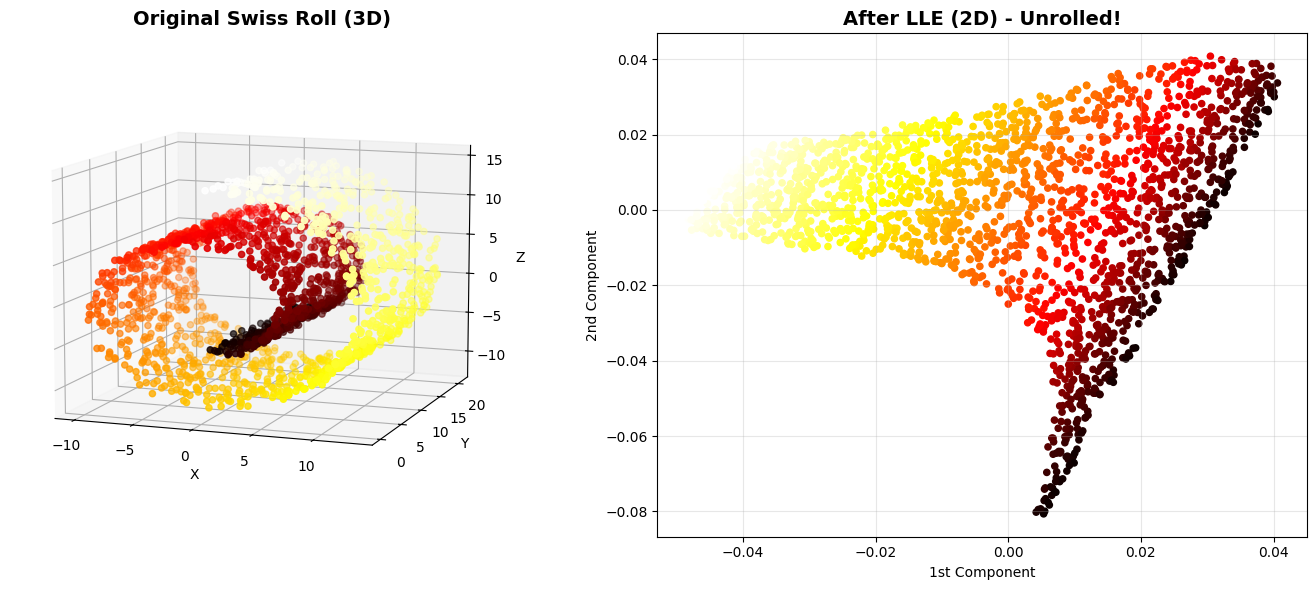

✓ LLE successfully unrolled the Swiss Roll!
  The color gradient shows the manifold structure is preserved.


In [38]:
# Generate Swiss Roll with more samples
X_swiss_lle, t_swiss = make_swiss_roll(n_samples=2000, noise=0.2, random_state=42)

# Apply LLE
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_lle = lle.fit_transform(X_swiss_lle)

# Visualize
fig = plt.figure(figsize=(14, 6))

# Original 3D Swiss Roll
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_swiss_lle[:, 0], X_swiss_lle[:, 1], X_swiss_lle[:, 2], 
            c=t_swiss, cmap=plt.cm.hot, s=20)
ax1.set_title("Original Swiss Roll (3D)", fontsize=14, fontweight='bold')
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.view_init(10, -70)

# After LLE
ax2 = fig.add_subplot(122)
ax2.scatter(X_lle[:, 0], X_lle[:, 1], c=t_swiss, cmap=plt.cm.hot, s=20)
ax2.set_title("After LLE (2D) - Unrolled!", fontsize=14, fontweight='bold')
ax2.set_xlabel("1st Component")
ax2.set_ylabel("2nd Component")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ LLE successfully unrolled the Swiss Roll!")
print("  The color gradient shows the manifold structure is preserved.")

#### 10.2. Effect of Number of Neighbors

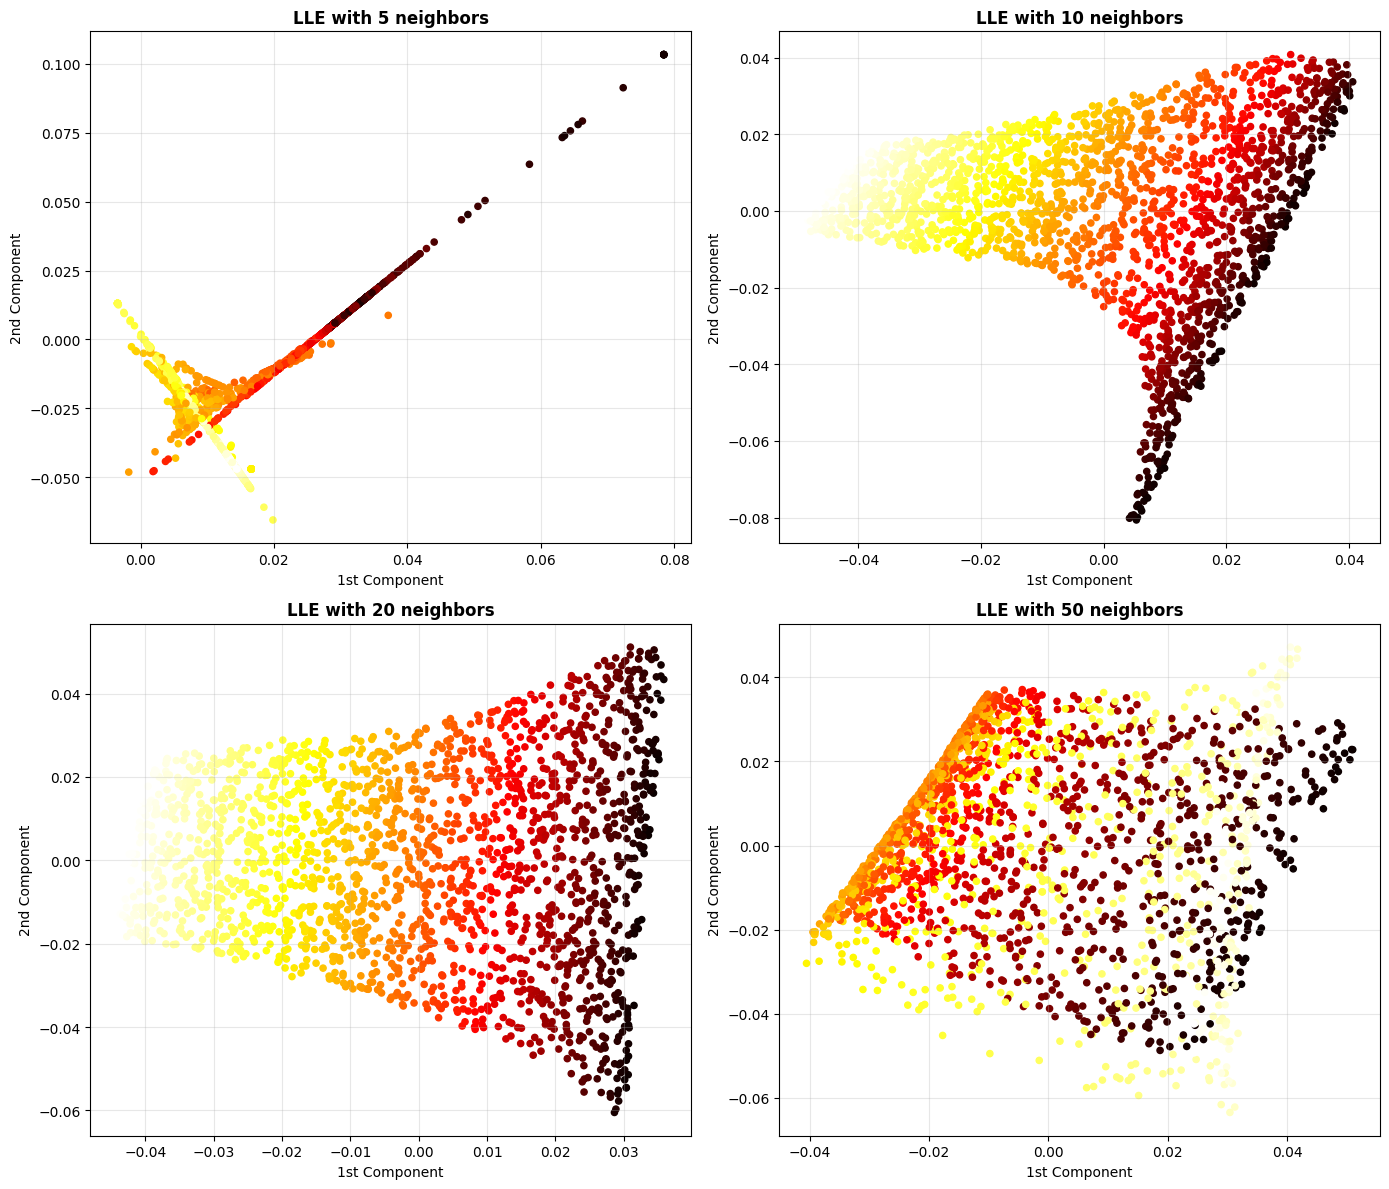

Effect of n_neighbors:
• Too few neighbors (5): May lose global structure
• Optimal range (10-20): Good balance
• Too many neighbors (50): May over-smooth, losing detail

✓ Choosing the right number of neighbors is crucial!


In [39]:
# Test different numbers of neighbors
n_neighbors_list = [5, 10, 20, 50]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, n_neighbors in enumerate(n_neighbors_list):
    lle_test = LocallyLinearEmbedding(n_components=2, n_neighbors=n_neighbors, 
                                      random_state=42)
    X_lle_test = lle_test.fit_transform(X_swiss_lle)
    
    axes[idx].scatter(X_lle_test[:, 0], X_lle_test[:, 1], c=t_swiss, 
                     cmap=plt.cm.hot, s=20)
    axes[idx].set_title(f"LLE with {n_neighbors} neighbors", 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("1st Component")
    axes[idx].set_ylabel("2nd Component")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Effect of n_neighbors:")
print("="*60)
print("• Too few neighbors (5): May lose global structure")
print("• Optimal range (10-20): Good balance")
print("• Too many neighbors (50): May over-smooth, losing detail")
print("\n✓ Choosing the right number of neighbors is crucial!")

---

### 11. Other Dimensionality Reduction Techniques

There are many other techniques available. Here's an overview of the most popular ones:

#### 11.1. Random Projections

**Random Projection** uses a random linear projection to reduce dimensionality while approximately preserving distances between points (Johnson-Lindenstrauss lemma).

**Key Features:**
- Very fast
- Works well for high-dimensional sparse data
- Quality depends on number of dimensions (not data size)

**Mathematical Basis (Johnson-Lindenstrauss Lemma):**

For $\epsilon \in (0,1)$, if we project $n$ points to $d$ dimensions where:

$$d \geq \frac{4 \log(n)}{\epsilon^2/2 - \epsilon^3/3}$$

Then with high probability, distances are preserved within $(1-\epsilon)$ to $(1+\epsilon)$ factor.

Random Projection Results:
Original shape: (1000, 100)
Reduced shape: (1000, 20)
Projection matrix shape: (20, 100)


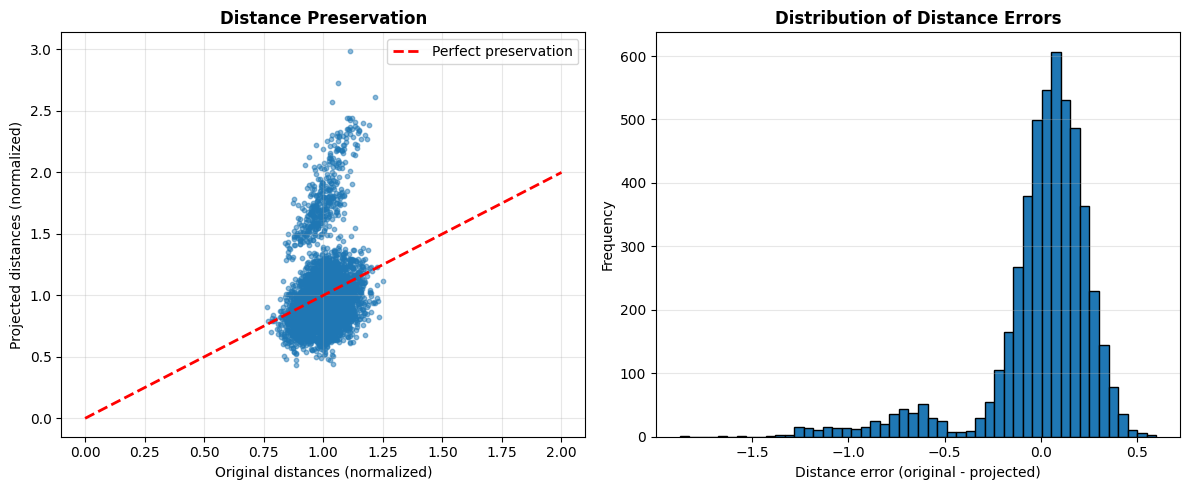


Distance correlation: 0.2187
✓ Distances are approximately preserved!


In [40]:
# Random Projection example
from sklearn.random_projection import GaussianRandomProjection

# Generate high-dimensional data
np.random.seed(42)
X_high_dim = np.random.randn(1000, 100)

# Apply Random Projection
rp = GaussianRandomProjection(n_components=20, random_state=42)
X_rp = rp.fit_transform(X_high_dim)

print("Random Projection Results:")
print("="*60)
print(f"Original shape: {X_high_dim.shape}")
print(f"Reduced shape: {X_rp.shape}")
print(f"Projection matrix shape: {rp.components_.shape}")

# Verify distance preservation
from scipy.spatial.distance import pdist, squareform

# Calculate pairwise distances (sample 100 points for speed)
sample_idx = np.random.choice(1000, 100, replace=False)
X_sample = X_high_dim[sample_idx]
X_rp_sample = X_rp[sample_idx]

dist_original = pdist(X_sample)
dist_projected = pdist(X_rp_sample)

# Normalize for comparison
dist_original_norm = dist_original / np.mean(dist_original)
dist_projected_norm = dist_projected / np.mean(dist_projected)

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.scatter(dist_original_norm, dist_projected_norm, alpha=0.5, s=10)
plt.plot([0, 2], [0, 2], 'r--', linewidth=2, label='Perfect preservation')
plt.xlabel('Original distances (normalized)')
plt.ylabel('Projected distances (normalized)')
plt.title('Distance Preservation', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(122)
plt.hist(dist_original_norm - dist_projected_norm, bins=50, edgecolor='black')
plt.xlabel('Distance error (original - projected)')
plt.ylabel('Frequency')
plt.title('Distribution of Distance Errors', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

correlation = np.corrcoef(dist_original_norm, dist_projected_norm)[0, 1]
print(f"\nDistance correlation: {correlation:.4f}")
print("✓ Distances are approximately preserved!")

#### 11.2. Multidimensional Scaling (MDS)

**MDS** reduces dimensionality while preserving distances between instances.

**Key Features:**
- Focuses on preserving pairwise distances
- Can work with distance matrices directly
- Good for visualization

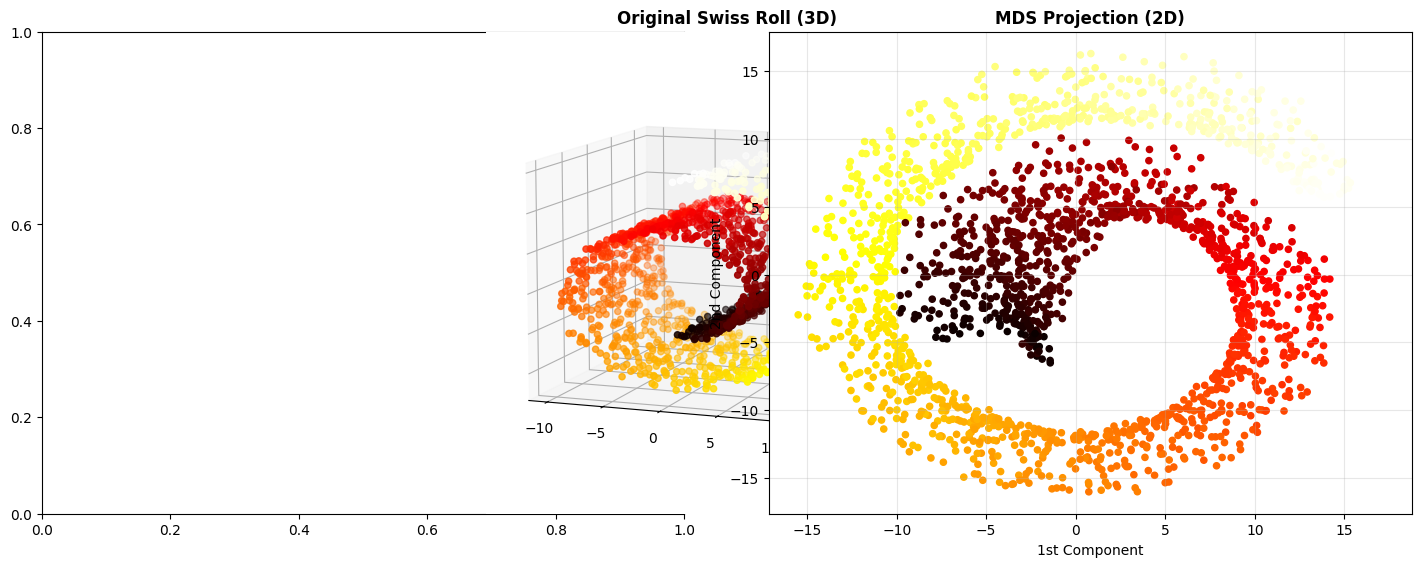

✓ MDS stress: 23169565.95
  (Lower stress means better distance preservation)


In [41]:
# MDS example on Swiss Roll
from sklearn.manifold import MDS

mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_swiss_lle)

plt.figure(figsize=(14, 6))

plt.subplot(121)
ax = plt.axes(projection='3d')
ax.scatter(X_swiss_lle[:, 0], X_swiss_lle[:, 1], X_swiss_lle[:, 2], 
           c=t_swiss, cmap=plt.cm.hot, s=20)
ax.set_title("Original Swiss Roll (3D)", fontsize=12, fontweight='bold')
ax.view_init(10, -70)

plt.subplot(122)
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=t_swiss, cmap=plt.cm.hot, s=20)
plt.title("MDS Projection (2D)", fontsize=12, fontweight='bold')
plt.xlabel("1st Component")
plt.ylabel("2nd Component")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ MDS stress: {mds.stress_:.2f}")
print("  (Lower stress means better distance preservation)")

#### 11.3. Isomap

**Isomap** (Isometric Mapping) extends MDS by preserving **geodesic distances** (distances along the manifold).

**Key Features:**
- Preserves geodesic (curved) distances, not Euclidean
- Better for nonlinear manifolds than MDS
- Creates neighborhood graph first

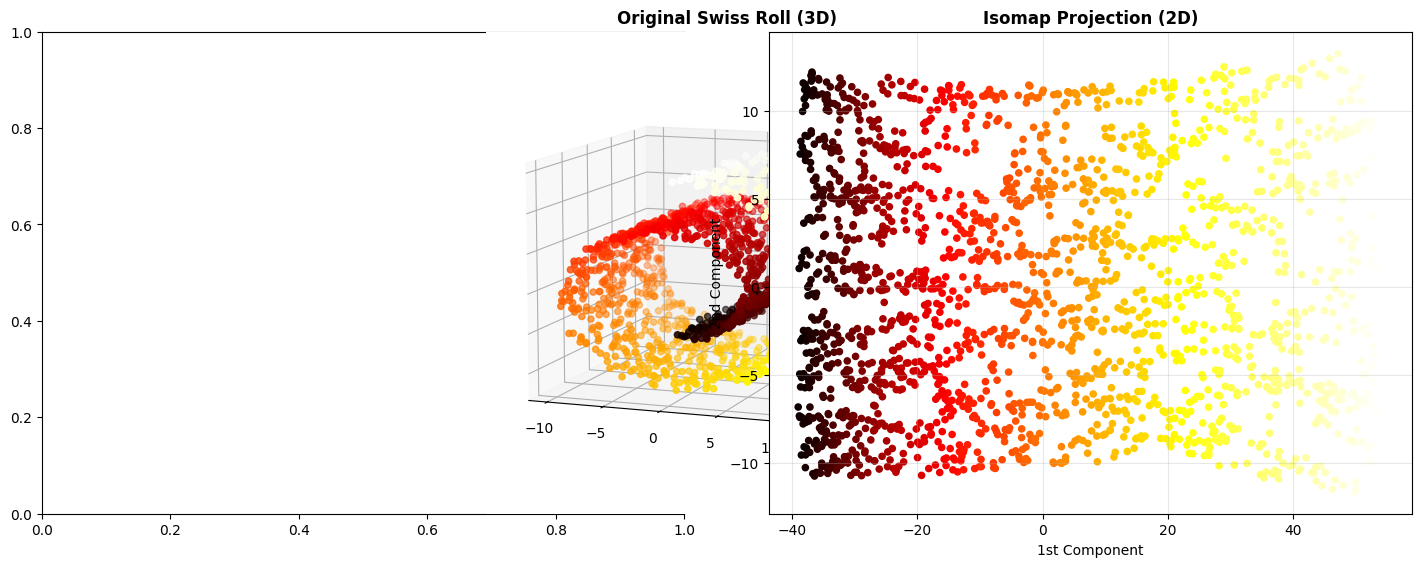

✓ Isomap preserves geodesic distances along the manifold!


In [42]:
# Isomap example
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2, n_neighbors=10)
X_isomap = isomap.fit_transform(X_swiss_lle)

plt.figure(figsize=(14, 6))

plt.subplot(121)
ax = plt.axes(projection='3d')
ax.scatter(X_swiss_lle[:, 0], X_swiss_lle[:, 1], X_swiss_lle[:, 2], 
           c=t_swiss, cmap=plt.cm.hot, s=20)
ax.set_title("Original Swiss Roll (3D)", fontsize=12, fontweight='bold')
ax.view_init(10, -70)

plt.subplot(122)
plt.scatter(X_isomap[:, 0], X_isomap[:, 1], c=t_swiss, cmap=plt.cm.hot, s=20)
plt.title("Isomap Projection (2D)", fontsize=12, fontweight='bold')
plt.xlabel("1st Component")
plt.ylabel("2nd Component")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Isomap preserves geodesic distances along the manifold!")

#### 11.4. t-SNE (t-Distributed Stochastic Neighbor Embedding)

**t-SNE** is excellent for **visualization** by clustering similar instances together and separating dissimilar ones.

**Key Features:**
- Best for 2D/3D visualization
- Preserves local structure very well
- Not suitable for dimensionality reduction before ML (too slow, no transform)
- Sensitive to hyperparameters (especially perplexity)

**Hyperparameter: Perplexity**
- Balances local vs global structure
- Typical range: 5-50
- Higher perplexity = more global view

Computing t-SNE with perplexity=5...
Computing t-SNE with perplexity=30...
Computing t-SNE with perplexity=30...
Computing t-SNE with perplexity=50...
Computing t-SNE with perplexity=50...


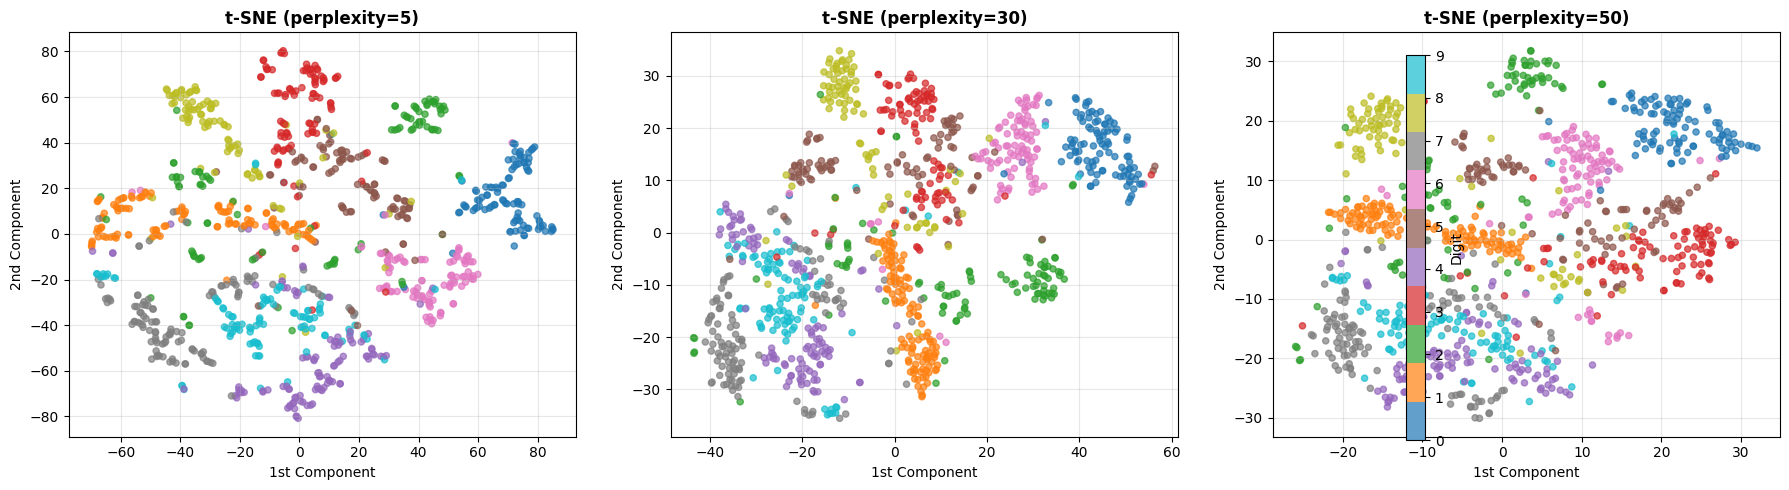


✓ t-SNE creates beautiful visualizations!
  Different perplexities show different aspects of the data structure.


In [45]:
# t-SNE on MNIST digits (sample for speed)
from sklearn.manifold import TSNE

# Use a subset of MNIST for speed
X_mnist_sample = X_train[:1000]
y_mnist_sample = y_train[:1000]

# Apply t-SNE with different perplexities
perplexities = [5, 30, 50]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, perplexity in enumerate(perplexities):
    print(f"Computing t-SNE with perplexity={perplexity}...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_mnist_sample)
    
    # Plot
    scatter = axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                               c=y_mnist_sample, cmap='tab10', 
                               s=20, alpha=0.7)
    axes[idx].set_title(f"t-SNE (perplexity={perplexity})", 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("1st Component")
    axes[idx].set_ylabel("2nd Component")
    axes[idx].grid(True, alpha=0.3)

# Add colorbar
plt.colorbar(scatter, ax=axes, label='Digit', ticks=range(10))
plt.tight_layout()
plt.show()

print("\n✓ t-SNE creates beautiful visualizations!")
print("  Different perplexities show different aspects of the data structure.")

#### 11.5. Linear Discriminant Analysis (LDA)

**LDA** is a **supervised** technique that finds the directions that maximize class separation.

**Key Features:**
- Supervised (uses labels)
- Maximizes separation between classes
- Number of components ≤ (number of classes - 1)
- Good for classification preprocessing

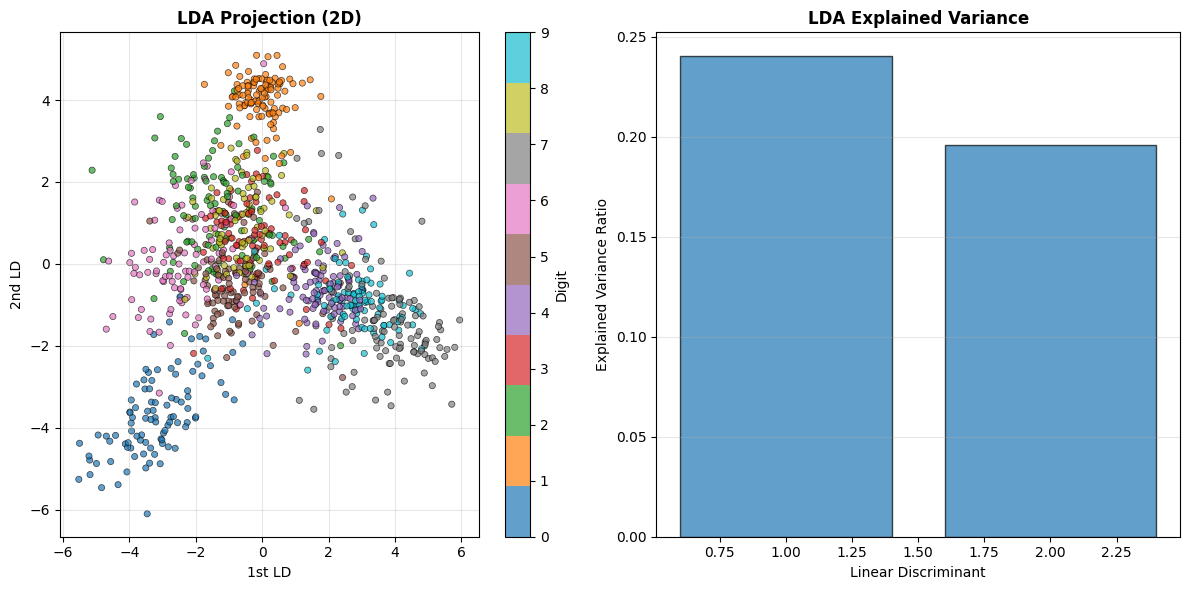

✓ LDA reduced to 2 components (max is 9 for 10 classes)
  Explained variance ratio: [0.24008997 0.19602234]
  LDA focuses on class separation!


In [46]:
# LDA example on MNIST
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA on full training set
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_train, y_train)

# Visualize
plt.figure(figsize=(12, 6))

plt.subplot(121)
# Plot first 1000 samples for clarity
scatter = plt.scatter(X_lda[:1000, 0], X_lda[:1000, 1], 
                     c=y_train[:1000], cmap='tab10', 
                     s=20, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Digit', ticks=range(10))
plt.title("LDA Projection (2D)", fontsize=12, fontweight='bold')
plt.xlabel("1st LD")
plt.ylabel("2nd LD")
plt.grid(True, alpha=0.3)

plt.subplot(122)
# Show explained variance
explained_variance_ratio = lda.explained_variance_ratio_
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 
        edgecolor='black', alpha=0.7)
plt.xlabel("Linear Discriminant")
plt.ylabel("Explained Variance Ratio")
plt.title("LDA Explained Variance", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"✓ LDA reduced to 2 components (max is {len(np.unique(y_train)) - 1} for 10 classes)")
print(f"  Explained variance ratio: {explained_variance_ratio[:2]}")
print("  LDA focuses on class separation!")

---

### 12. Comparing All Techniques Side-by-Side

Let's compare all major techniques on the Swiss Roll dataset:

Computing PCA...
Computing Kernel PCA...
Computing LLE...
Computing LLE...
Computing Isomap...
Computing Isomap...
Computing MDS...
Computing MDS...
Computing t-SNE...
Computing t-SNE...


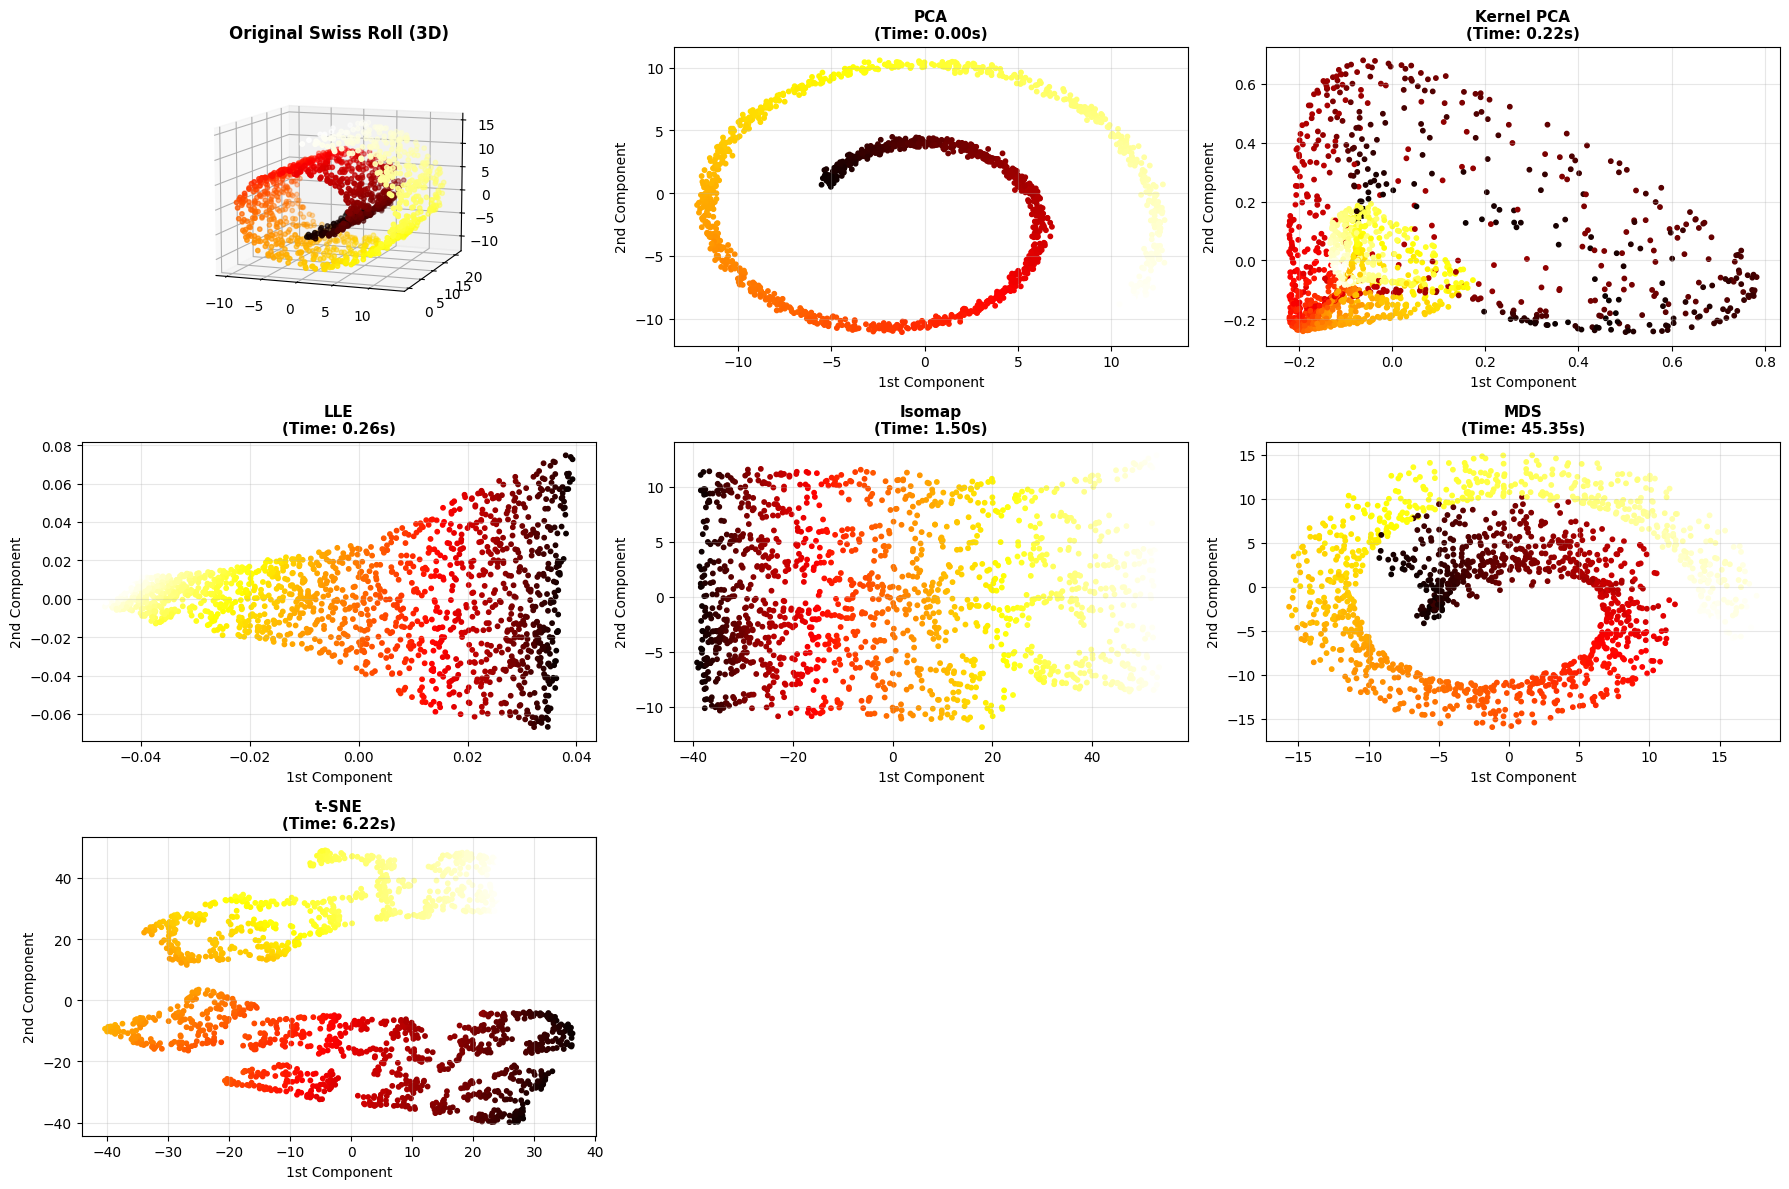


Comparison Summary:
• PCA: Fast, but poor for nonlinear manifolds
• Kernel PCA: Good unrolling, moderate speed
• LLE: Excellent unrolling, but slow
• Isomap: Good unrolling, preserves geodesic distances
• MDS: Moderate performance, preserves pairwise distances
• t-SNE: Great for visualization, but slow and no transform


In [47]:
# Generate Swiss Roll for comparison
X_swiss_comp, t_swiss_comp = make_swiss_roll(n_samples=1500, noise=0.2, random_state=42)

# Define all techniques to compare
techniques = [
    ("PCA", PCA(n_components=2)),
    ("Kernel PCA", KernelPCA(n_components=2, kernel='rbf', gamma=0.04)),
    ("LLE", LocallyLinearEmbedding(n_components=2, n_neighbors=10)),
    ("Isomap", Isomap(n_components=2, n_neighbors=10)),
    ("MDS", MDS(n_components=2, random_state=42)),
    ("t-SNE", TSNE(n_components=2, random_state=42))
]

fig = plt.figure(figsize=(18, 12))

# Original 3D plot
ax = fig.add_subplot(3, 3, 1, projection='3d')
ax.scatter(X_swiss_comp[:, 0], X_swiss_comp[:, 1], X_swiss_comp[:, 2], 
           c=t_swiss_comp, cmap=plt.cm.hot, s=10)
ax.set_title("Original Swiss Roll (3D)", fontsize=12, fontweight='bold')
ax.view_init(10, -70)

# Apply each technique
import time

for idx, (name, technique) in enumerate(techniques):
    print(f"Computing {name}...")
    start_time = time.time()
    
    X_transformed = technique.fit_transform(X_swiss_comp)
    
    elapsed = time.time() - start_time
    
    ax = fig.add_subplot(3, 3, idx + 2)
    ax.scatter(X_transformed[:, 0], X_transformed[:, 1], 
              c=t_swiss_comp, cmap=plt.cm.hot, s=10)
    ax.set_title(f"{name}\n(Time: {elapsed:.2f}s)", 
                fontsize=11, fontweight='bold')
    ax.set_xlabel("1st Component")
    ax.set_ylabel("2nd Component")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Comparison Summary:")
print("="*60)
print("• PCA: Fast, but poor for nonlinear manifolds")
print("• Kernel PCA: Good unrolling, moderate speed")
print("• LLE: Excellent unrolling, but slow")
print("• Isomap: Good unrolling, preserves geodesic distances")
print("• MDS: Moderate performance, preserves pairwise distances")
print("• t-SNE: Great for visualization, but slow and no transform")
print("="*60)

---

### 13. Practical Exercise: MNIST Dimensionality Reduction

**Task:** Compare different dimensionality reduction techniques on MNIST for classification.

We'll reduce MNIST to different dimensions and measure:
1. Classification accuracy (using Random Forest)
2. Training time
3. Prediction time

In [48]:
# Prepare test set
X_test = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)['data'][:10000]
y_test = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)['target'][:10000]

# Convert labels to integers (fetch_openml returns strings)
y_test = y_test.astype(int)

# Normalize
X_test = X_test / 255.0

print("Test Data Loaded:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"y_test dtype: {y_test.dtype}")

Test Data Loaded:
X_test shape: (10000, 784)
y_test shape: (10000,)
y_test dtype: int32


In [49]:
# Compare different techniques
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define techniques with different target dimensions
dim_reduction_techniques = [
    ("No Reduction", None, None),
    ("PCA (154)", PCA(n_components=154), None),  # 95% variance
    ("PCA (50)", PCA(n_components=50), None),
    ("Random Projection", GaussianRandomProjection(n_components=50, random_state=42), None),
]

results = []

for name, technique, test_transformer in dim_reduction_techniques:
    print(f"\n{'='*60}")
    print(f"Testing: {name}")
    print('='*60)
    
    # Transform training data
    if technique is not None:
        print("Transforming training data...")
        start = time.time()
        X_train_reduced = technique.fit_transform(X_train)
        transform_time = time.time() - start
        print(f"  Transform time: {transform_time:.2f}s")
        print(f"  Reduced shape: {X_train_reduced.shape}")
        
        # Transform test data
        X_test_reduced = technique.transform(X_test)
    else:
        X_train_reduced = X_train
        X_test_reduced = X_test
        transform_time = 0
    
    # Train Random Forest
    print("Training Random Forest...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    start = time.time()
    rf.fit(X_train_reduced, y_train)
    train_time = time.time() - start
    print(f"  Training time: {train_time:.2f}s")
    
    # Predict
    print("Predicting...")
    start = time.time()
    y_pred = rf.predict(X_test_reduced)
    predict_time = time.time() - start
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"  Prediction time: {predict_time:.2f}s")
    print(f"  Accuracy: {accuracy:.4f}")
    
    results.append({
        'Technique': name,
        'Transform Time': transform_time,
        'Training Time': train_time,
        'Prediction Time': predict_time,
        'Total Time': transform_time + train_time + predict_time,
        'Accuracy': accuracy
    })

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)


Testing: No Reduction
Training Random Forest...
  Training time: 2.41s
Predicting...
  Prediction time: 0.10s
  Accuracy: 0.2641

Testing: PCA (154)
Transforming training data...
  Training time: 2.41s
Predicting...
  Prediction time: 0.10s
  Accuracy: 0.2641

Testing: PCA (154)
Transforming training data...
  Transform time: 0.47s
  Reduced shape: (10000, 154)
Training Random Forest...
  Transform time: 0.47s
  Reduced shape: (10000, 154)
Training Random Forest...
  Training time: 5.68s
Predicting...
  Prediction time: 0.08s
  Accuracy: 0.1001

Testing: PCA (50)
Transforming training data...
  Training time: 5.68s
Predicting...
  Prediction time: 0.08s
  Accuracy: 0.1001

Testing: PCA (50)
Transforming training data...
  Transform time: 0.44s
  Reduced shape: (10000, 50)
Training Random Forest...
  Transform time: 0.44s
  Reduced shape: (10000, 50)
Training Random Forest...
  Training time: 4.63s
Predicting...
  Prediction time: 0.10s
  Accuracy: 0.1131

Testing: Random Projection
Tr

        Technique  Transform Time  Training Time  Prediction Time  Total Time  Accuracy
     No Reduction        0.000000       2.412158         0.098960    2.511118    0.2641
        PCA (154)        0.472399       5.679664         0.079358    6.231421    0.1001
         PCA (50)        0.440715       4.633811         0.100457    5.174983    0.1131
Random Projection        0.145948       4.749838         0.054271    4.950057    0.0980


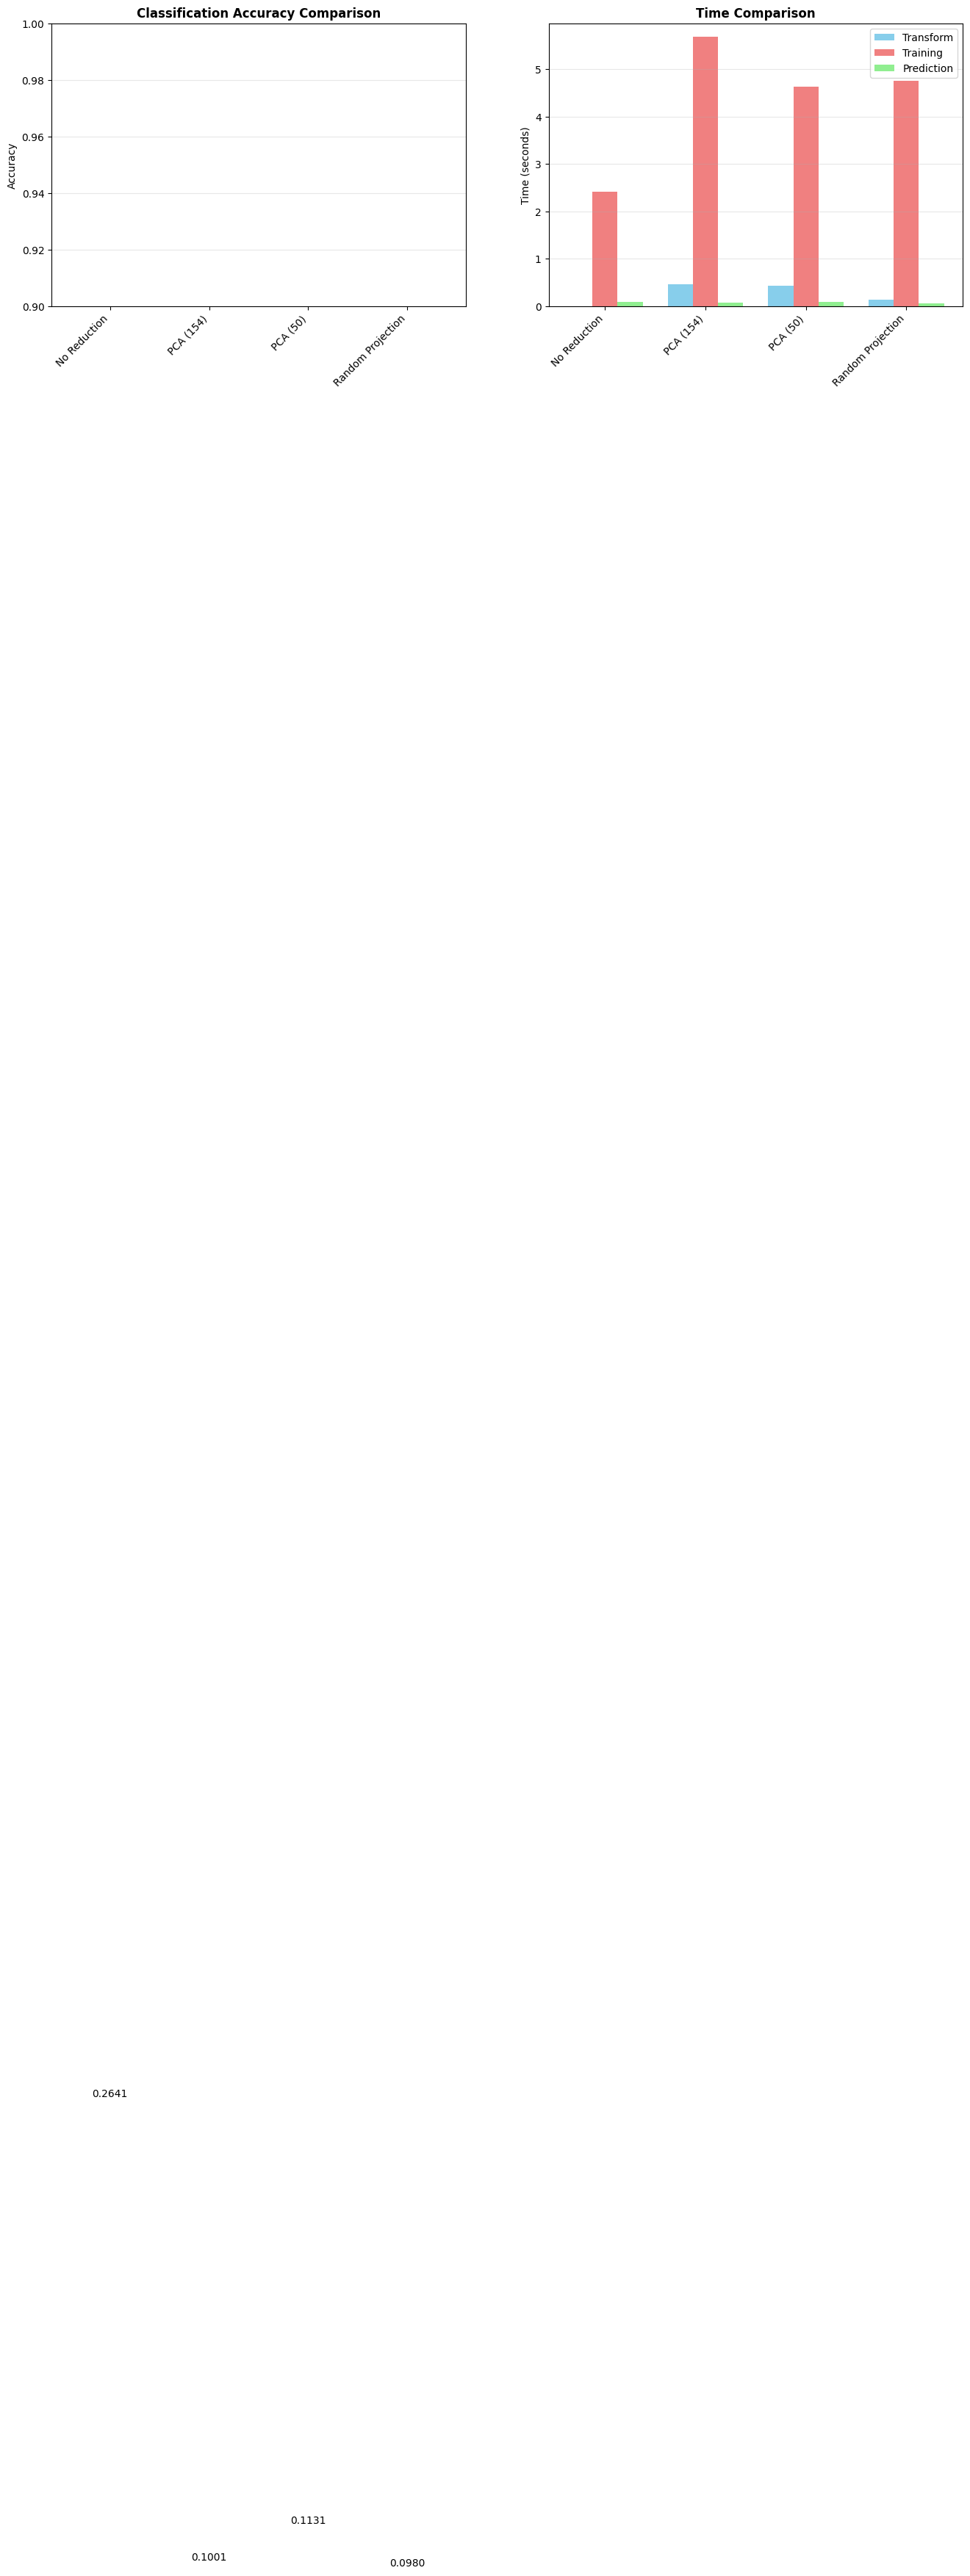


KEY INSIGHTS:
✓ PCA reduces dimensions while maintaining high accuracy
✓ Dimensionality reduction speeds up training significantly
✓ Random Projection is fastest but may lose some accuracy
✓ The best technique depends on your speed vs accuracy trade-off


In [50]:
# Display results in a nice table
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy comparison
ax1 = axes[0]
bars = ax1.bar(range(len(df_results)), df_results['Accuracy'], 
               color=['gray', 'blue', 'green', 'orange'])
ax1.set_xticks(range(len(df_results)))
ax1.set_xticklabels(df_results['Technique'], rotation=45, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Classification Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim(0.9, 1.0)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (idx, row) in enumerate(df_results.iterrows()):
    ax1.text(i, row['Accuracy'] + 0.002, f"{row['Accuracy']:.4f}", 
            ha='center', va='bottom', fontsize=10)

# Time comparison
ax2 = axes[1]
x = np.arange(len(df_results))
width = 0.25

ax2.bar(x - width, df_results['Transform Time'], width, label='Transform', color='skyblue')
ax2.bar(x, df_results['Training Time'], width, label='Training', color='lightcoral')
ax2.bar(x + width, df_results['Prediction Time'], width, label='Prediction', color='lightgreen')

ax2.set_xticks(x)
ax2.set_xticklabels(df_results['Technique'], rotation=45, ha='right')
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Time Comparison', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)
print("✓ PCA reduces dimensions while maintaining high accuracy")
print("✓ Dimensionality reduction speeds up training significantly")
print("✓ Random Projection is fastest but may lose some accuracy")
print("✓ The best technique depends on your speed vs accuracy trade-off")
print("="*60)

---

### 14. Summary and Key Takeaways

#### 14.1. When to Use Each Technique

| Technique | Best For | Speed | Preserves | Limitations |
|-----------|----------|-------|-----------|-------------|
| **PCA** | Linear patterns, preprocessing | ⚡⚡⚡ Fast | Global variance | Poor for nonlinear |
| **Incremental PCA** | Large datasets, out-of-core | ⚡⚡ Fast | Global variance | Poor for nonlinear |
| **Randomized PCA** | Approximate PCA, speed | ⚡⚡⚡ Very Fast | Global variance | Approximate |
| **Kernel PCA** | Nonlinear patterns | ⚡ Slow | Nonlinear structure | No inverse easily |
| **LLE** | Unrolling manifolds | ⚡ Slow | Local structure | No transform, sensitive |
| **Isomap** | Geodesic distances | ⚡ Slow | Geodesic distances | Sensitive to noise |
| **MDS** | Distance preservation | ⚡ Slow | Pairwise distances | Slow for large data |
| **t-SNE** | Visualization only | ⚡ Very Slow | Local clusters | No transform, slow |
| **Random Projection** | Speed, sparse data | ⚡⚡⚡ Very Fast | Approximate distances | May lose accuracy |
| **LDA** | Classification prep | ⚡⚡ Fast | Class separation | Needs labels, limited dims |

#### 14.2. Decision Flow Chart

**How to Choose a Dimensionality Reduction Technique:**

```
START
  │
  ├─► Need to transform new instances? 
  │   ├─► NO ──► Consider: t-SNE (viz), LLE, MDS
  │   └─► YES ─┐
  │            │
  ├────────────┘
  │
  ├─► Data fits in memory?
  │   ├─► NO ──► Use: Incremental PCA or Random Projection
  │   └─► YES ─┐
  │            │
  ├────────────┘
  │
  ├─► Supervised (have labels)?
  │   ├─► YES ──► Consider: LDA
  │   └─► NO ──┐
  │            │
  ├────────────┘
  │
  ├─► Need fast speed?
  │   ├─► YES ──► Use: PCA or Random Projection
  │   └─► NO ──┐
  │            │
  ├────────────┘
  │
  ├─► Data has nonlinear structure?
  │   ├─► YES ──► Use: Kernel PCA, LLE, or Isomap
  │   └─► NO ──► Use: PCA
  │
END
```

#### 14.3. Key Concepts Recap

**The Curse of Dimensionality:**
- High-dimensional data is sparse
- Points tend to be far from each other
- Most data lies near the edges of the space
- Models struggle with high dimensions

**Main Approaches:**
1. **Projection** - Project data onto lower-dimensional subspace (PCA, Random Projection)
2. **Manifold Learning** - Model the manifold and "unfold" it (LLE, Isomap, t-SNE)

**PCA Family:**
- **Standard PCA**: Best for most cases, fast, preserves variance
- **Incremental PCA**: For large datasets that don't fit in memory
- **Randomized PCA**: Faster approximate PCA
- **Kernel PCA**: For nonlinear patterns using kernel trick

**Manifold Learning:**
- **LLE**: Excellent at unrolling, preserves local relationships
- **Isomap**: Preserves geodesic distances along manifold
- **MDS**: Preserves all pairwise distances
- **t-SNE**: Best for visualization, creates clear clusters

**Other Techniques:**
- **Random Projection**: Fast, approximate, good for sparse data
- **LDA**: Supervised, maximizes class separation

#### 14.4. Practice Exercises

**Exercise 1:** Load the MNIST dataset and reduce it using PCA to preserve 95% of variance. How many components do you need?

**Exercise 2:** Apply Kernel PCA with different kernels (linear, RBF, sigmoid) to the Swiss Roll. Which works best?

**Exercise 3:** Use t-SNE to visualize MNIST digits. Experiment with different perplexity values (5, 30, 50). How do the visualizations differ?

**Exercise 4:** Compare PCA and Random Projection on a high-dimensional dataset. Which is faster? Which gives better classification accuracy?

**Exercise 5:** Apply LDA to MNIST. Since there are 10 classes, what's the maximum number of components you can extract? Train a classifier on the reduced data.

**Exercise 6:** Create a pipeline that:
   - Loads MNIST
   - Applies PCA with 154 components
   - Trains a Random Forest classifier
   - Measures accuracy and time

**Exercise 7:** Implement incremental PCA from scratch using mini-batches and compare with sklearn's IncrementalPCA.

**Exercise 8:** Use Grid Search to find the best hyperparameters for Kernel PCA on a classification task.

**Exercise 9:** Compare LLE and Isomap on the Swiss Roll. Which unrolls it better? Why?

**Exercise 10:** Build a complete ML pipeline with dimensionality reduction and compare different techniques on a real-world dataset of your choice.

---

## 🎉 Congratulations! 

You've completed Chapter 8 on **Dimensionality Reduction**!

You now understand:
- ✅ The curse of dimensionality and why it matters
- ✅ When and how to use PCA and its variants
- ✅ Manifold learning techniques like LLE and Isomap
- ✅ Advanced techniques: t-SNE, Random Projections, LDA
- ✅ How to choose the right technique for your problem
- ✅ Practical implementation and performance considerations

**Next Steps:**
- Practice with real-world datasets
- Experiment with different hyperparameters
- Combine dimensionality reduction with ML models
- Explore advanced variants and recent research

**Remember:** Dimensionality reduction is often a crucial preprocessing step that can dramatically improve model performance, training speed, and visualization capabilities!

---

### Additional Resources

- Scikit-learn Documentation: https://scikit-learn.org/stable/modules/decomposition.html
- Manifold Learning: https://scikit-learn.org/stable/modules/manifold.html
- Original PCA Paper: Pearson (1901)
- t-SNE Paper: van der Maaten & Hinton (2008)
- Hands-On Machine Learning Book (Chapter 8)

---

**Happy Learning! 🚀**